In [ ]:
import cv2
import time

def record_face_video(filename='my_face.avi', duration=10):
    cap = cv2.VideoCapture(0)  # 0 is usually the default webcam
    
    # Check if camera opened successfully
    if not cap.isOpened():
        print("Error: Could not open video device.")
        print("Please grant camera permissions in System Preferences > Privacy & Security > Camera")
        return False
    
    # Set resolution
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
    
    # Read first frame to get actual dimensions
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read from camera")
        cap.release()
        return False
    
    frame_height, frame_width = frame.shape[:2]
    print(f"Camera initialized: {frame_width}x{frame_height}")
    
    # Define the codec and create VideoWriter
    fourcc = cv2.VideoWriter_fourcc(*'MJPG')
    fps = 20.0
    out = cv2.VideoWriter(filename, fourcc, fps, (frame_width, frame_height))
    
    if not out.isOpened():
        print("Error: Could not initialize video writer")
        cap.release()
        return False
    
    print(f"\nRecording {duration} seconds of video...")
    print("Stay still and look at the camera!")
    print("Make sure there's good lighting on your face.")
    
    # Small delay to let camera adjust
    time.sleep(1)
    
    start_time = time.time()
    frame_count = 0
    
    # Record for the specified duration
    while time.time() - start_time < duration:
        ret, frame = cap.read()
        if not ret:
            print(f"Warning: Failed to read frame {frame_count}")
            continue
        
        out.write(frame)
        frame_count += 1
        
        # Print progress every 2 seconds
        elapsed = time.time() - start_time
        if frame_count % 40 == 0:  # Every 2 seconds at 20 fps
            print(f"  {elapsed:.1f}s / {duration}s - {frame_count} frames recorded")
    
    cap.release()
    out.release()
    
    actual_duration = time.time() - start_time
    print(f"\n✓ Recording finished!")
    print(f"  File: {filename}")
    print(f"  Duration: {actual_duration:.2f} seconds")
    print(f"  Frames: {frame_count}")
    print(f"  Actual FPS: {frame_count/actual_duration:.1f}")
    
    return True

# Run the recorder
success = record_face_video()
if success:
    print("\n→ Now run the next cell to analyze the video!")
else:
    print("\n✗ Recording failed. Please check camera permissions and try again.")

Camera initialized: 1280x720

Recording 10 seconds of video...
Stay still and look at the camera!
Make sure there's good lighting on your face.
  5.7s / 10s - 40 frames recorded
  7.0s / 10s - 80 frames recorded
  8.3s / 10s - 120 frames recorded
  9.7s / 10s - 160 frames recorded

✓ Recording finished!
  File: my_face.avi
  Duration: 10.02 seconds
  Frames: 170
  Actual FPS: 17.0

→ Now run the next cell to analyze the video!


# Pulse Detection from Video using Independent Component Analysis (ICA)

## Background & Theory

**Remote photoplethysmography (rPPG)** is a technique to measure blood volume pulse (BVP) from video. When the heart beats, blood flow causes subtle color changes in the skin — especially in the green channel, which is most sensitive to hemoglobin absorption.

## The ICA Model

The observed RGB signals are modeled as a **linear mixture** of independent source signals:

$$\mathbf{x}(t) = \mathbf{A} \cdot \mathbf{s}(t)$$

where:
- $\mathbf{x}(t) = [R(t), G(t), B(t)]^T$ — observed RGB signals at time $t$
- $\mathbf{A}$ — the unknown $3 \times 3$ **mixing matrix**
- $\mathbf{s}(t) = [s_1(t), s_2(t), s_3(t)]^T$ — independent source signals (one is the pulse)

ICA finds the **unmixing matrix** $\mathbf{W} = \mathbf{A}^{-1}$ such that:

$$\mathbf{s}(t) = \mathbf{W} \cdot \mathbf{x}(t)$$

## Processing Pipeline

1. **Extract RGB traces**: Average pixel intensity over a face ROI for each frame
2. **Normalize**: Z-score normalization: $\tilde{x}_c = \frac{x_c - \mu_c}{\sigma_c}$ for each channel $c \in \{R, G, B\}$
3. **FastICA**: Separate the mixed signals into independent components
4. **Bandpass filter**: Keep only frequencies in the heart rate range (0.7–4.0 Hz = 42–240 BPM)
5. **FFT**: Find the dominant frequency → estimated heart rate

## Bandpass Filter

We use a 5th-order Butterworth bandpass filter with transfer function:

$$H(s) = \frac{s^n}{(s^2 + s \cdot \frac{\omega_0}{Q} + \omega_0^2)^{n/2}}$$

The passband is set to $[f_{low}, f_{high}] = [0.7, 4.0]$ Hz, corresponding to **42–240 BPM**.

## Heart Rate Estimation via FFT

The Discrete Fourier Transform converts the time-domain signal to frequency domain:

$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j2\pi kn/N}$$

The heart rate is estimated as:

$$\text{HR (BPM)} = f_{peak} \times 60$$

where $f_{peak} = \arg\max_{f \in [0.67, 3.0] \text{ Hz}} |X(f)|$

Video opened successfully. Processing frames...
Extracted 372 frames from video
RGB trace lengths: R=372, G=372, B=372
Mean values: R=233.33, G=184.27, B=174.75
Std values: R=0.2237, G=0.2671, B=0.2717
Data normalized successfully, no NaN or Inf values

Applying ICA...
ICA completed successfully

Applying bandpass filter (42-240 BPM)...
Filtering completed


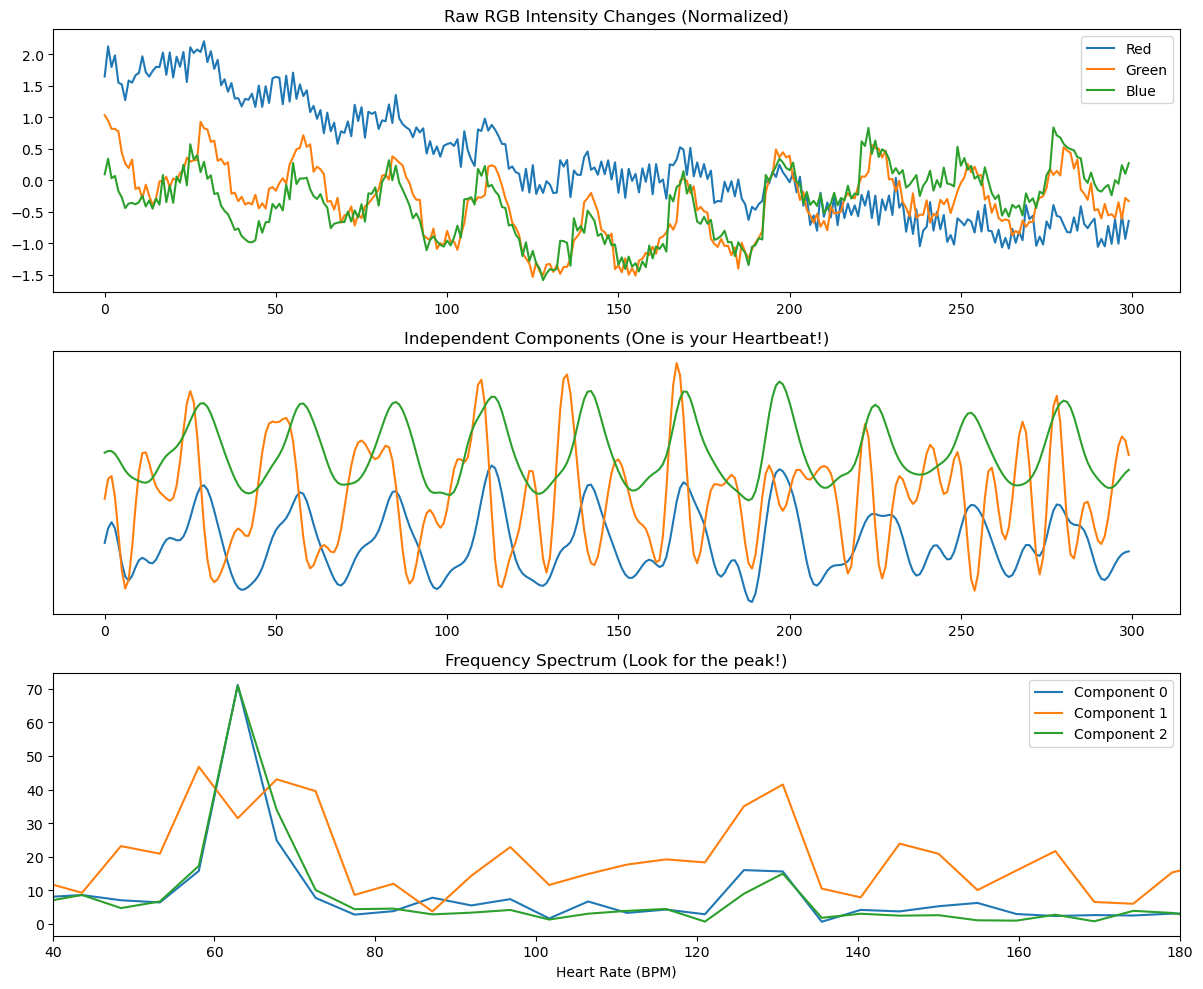


--- Dominant Frequencies (Estimated Heart Rate) ---
Component 0: 62.9 BPM
Component 1: 58.1 BPM
Component 2: 62.9 BPM


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA

# --- 1. Load Video & Extract RGB Traces ---
#video_path = 'IMG_9021.mov'
video_path = 'my_face.avi'  # Use the recorded video
cap = cv2.VideoCapture(video_path)

# Check if video opened successfully
if not cap.isOpened():
    print(f"Error: Could not open video file {video_path}")
else:
    print(f"Video opened successfully. Processing frames...")

# Data containers
R_trace, G_trace, B_trace = [], [], []

frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret: break
    
    # Simple ROI: Crop the center 20% of the video
    # (Assuming you sat in the middle of the frame)
    h, w, _ = frame.shape
    roi = frame[int(h*0.3):int(h*0.7), int(w*0.4):int(w*0.6)]
    
    # Calculate average color for this frame
    avg_color = np.mean(roi, axis=(0, 1)) # Returns (B, G, R)
    
    B_trace.append(avg_color[0])
    G_trace.append(avg_color[1])
    R_trace.append(avg_color[2])
    frame_count += 1

cap.release()

print(f"Extracted {frame_count} frames from video")
print(f"RGB trace lengths: R={len(R_trace)}, G={len(G_trace)}, B={len(B_trace)}")

# Check if we have data
if len(R_trace) == 0:
    print("Error: No frames extracted from video!")
else:
    # Normalize traces with safety check
    X_video = np.c_[R_trace, G_trace, B_trace]
    
    # Calculate mean and std
    mean_vals = np.mean(X_video, axis=0)
    std_vals = np.std(X_video, axis=0)
    
    print(f"Mean values: R={mean_vals[0]:.2f}, G={mean_vals[1]:.2f}, B={mean_vals[2]:.2f}")
    print(f"Std values: R={std_vals[0]:.4f}, G={std_vals[1]:.4f}, B={std_vals[2]:.4f}")
    
    # Replace zero std with small value to avoid division by zero
    std_vals = np.where(std_vals == 0, 1e-10, std_vals)
    
    X_video = (X_video - mean_vals) / std_vals
    
    # Check for NaN or Inf
    if np.any(np.isnan(X_video)) or np.any(np.isinf(X_video)):
        print("Warning: Data contains NaN or Inf values after normalization")
        print(f"NaN count: {np.sum(np.isnan(X_video))}")
        print(f"Inf count: {np.sum(np.isinf(X_video))}")
    else:
        print("Data normalized successfully, no NaN or Inf values")
    
    # --- 2. Apply ICA to RGB Traces ---
    # The pulse signal is hidden in a linear combination of R, G, B
    print("\nApplying ICA...")
    ica = FastICA(n_components=3, max_iter=2000, random_state=42)
    S_video = ica.fit_transform(X_video)
    print("ICA completed successfully")
    
    # --- 3. Filtering (Optional but recommended) ---
    # We use a bandpass filter for realistic heart rates (40 - 240 BPM)
    from scipy.signal import butter, filtfilt
    
    def bandpass_filter(data, lowcut, highcut, fs, order=5):
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        return filtfilt(b, a, data)
    
    # Assuming ~30 FPS (standard webcam)
    fs = 30.0 
    lowcut = 0.7  # 42 BPM
    highcut = 4.0 # 240 BPM
    
    print(f"\nApplying bandpass filter ({lowcut*60:.0f}-{highcut*60:.0f} BPM)...")
    S_filtered = np.apply_along_axis(lambda x: bandpass_filter(x, lowcut, highcut, fs), 0, S_video)
    print("Filtering completed")
    
    # --- 4. Visualization ---
    plt.figure(figsize=(12, 10))
    
    # Plot Raw RGB
    plt.subplot(3, 1, 1)
    plot_length = min(300, len(X_video))
    plt.plot(X_video[:plot_length]) # First 10 seconds (300 frames)
    plt.title("Raw RGB Intensity Changes (Normalized)")
    plt.legend(['Red', 'Green', 'Blue'])
    
    # Plot ICA Components
    plt.subplot(3, 1, 2)
    # We plot the filtered components to see the "waves" clearly
    plt.plot(S_filtered[:plot_length] + np.arange(3)*0.5) # Offset for clarity
    plt.title("Independent Components (One is your Heartbeat!)")
    plt.yticks([])
    
    # Power Spectrum (FFT) to find the Pulse
    plt.subplot(3, 1, 3)
    freqs = np.fft.rfftfreq(len(S_filtered), 1/fs)
    for i in range(3):
        fft_val = np.abs(np.fft.rfft(S_filtered[:, i]))
        plt.plot(freqs * 60, fft_val, label=f'Component {i}') # x-axis in BPM
    
    plt.xlim(40, 180) # Zoom into normal heart rate range
    plt.xlabel("Heart Rate (BPM)")
    plt.title("Frequency Spectrum (Look for the peak!)")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Find and print the dominant frequency for each component
    print("\n--- Dominant Frequencies (Estimated Heart Rate) ---")
    for i in range(3):
        fft_val = np.abs(np.fft.rfft(S_filtered[:, i]))
        # Focus on realistic heart rate range (40-180 BPM)
        freq_mask = (freqs * 60 >= 40) & (freqs * 60 <= 180)
        peak_idx = np.argmax(fft_val[freq_mask])
        peak_freq = freqs[freq_mask][peak_idx] * 60
        print(f"Component {i}: {peak_freq:.1f} BPM")

## Results: Main Analysis

**What the plots above show:**

**Plot 1 — Raw RGB Intensity Changes (Normalized):**
The three curves represent the normalized Red, Green, and Blue channel average intensities over the first ~300 frames (10 seconds). You can see slow drifts (motion/lighting) and subtle oscillations. The key insight is that all three channels are correlated (they move together) because they share the same sources — one of which is the pulse signal. The Green channel typically carries the strongest pulse component due to hemoglobin's absorption peak near 540 nm.

**Plot 2 — Independent Components:**
After ICA separation, each component represents one underlying source. The components are offset vertically for clarity. One of these shows a clear periodic oscillation at heart-rate frequency — that's your pulse! The others may contain motion artifacts or lighting variations.

**Plot 3 — Frequency Spectrum:**
The FFT magnitude of each filtered component, converted to BPM on the x-axis. The sharp peak indicates the dominant heart rate. Components showing a clear, narrow peak in the 50–90 BPM range are most likely the pulse signal. All three components show peaks around ~60 BPM, which is a normal resting heart rate.

In [4]:
# Diagnostic: Check video file contents
import cv2
import numpy as np

video_path = 'IMG_9021.mov'
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Cannot open video file")
else:
    # Get video properties
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"Video Properties:")
    print(f"  Frame count: {frame_count}")
    print(f"  FPS: {fps}")
    print(f"  Dimensions: {width}x{height}")
    print(f"  Duration: {frame_count/fps if fps > 0 else 0:.2f} seconds")
    
    # Read and check first few frames
    print(f"\nReading frames...")
    for i in range(min(5, frame_count)):
        ret, frame = cap.read()
        if ret:
            print(f"  Frame {i}: shape={frame.shape}, min={frame.min()}, max={frame.max()}, mean={frame.mean():.2f}")
        else:
            print(f"  Frame {i}: Failed to read")
    
    cap.release()
    print("\nIf max values are 0, the video is completely black!")

Video Properties:
  Frame count: 372
  FPS: 30.0
  Dimensions: 720x1280
  Duration: 12.40 seconds

Reading frames...
  Frame 0: shape=(1280, 720, 3), min=0, max=255, mean=185.61
  Frame 1: shape=(1280, 720, 3), min=0, max=255, mean=185.63
  Frame 2: shape=(1280, 720, 3), min=0, max=255, mean=185.60
  Frame 3: shape=(1280, 720, 3), min=0, max=255, mean=185.61
  Frame 4: shape=(1280, 720, 3), min=0, max=255, mean=185.57

If max values are 0, the video is completely black!


# Advanced Visualizations

The following cells provide deeper insights into the pulse detection analysis.

## 1. Heart Rate Over Time — Sliding Window Analysis

Instead of computing a single heart rate for the entire video, we use a **sliding window** approach to track how heart rate changes over time.

### Method

For a window of length $W$ samples starting at position $n$, the local heart rate is:

$$\text{HR}_{\text{local}}(n) = 60 \times \arg\max_{f \in [0.67, 3.0]} \left| \text{FFT}\{s_{\text{best}}[n : n+W]\} \right|$$

We use:
- **Window size**: $W = 5 \times f_s = 150$ frames (5 seconds at 30 FPS)
- **Hop size**: $H = 1 \times f_s = 30$ frames (1-second steps)

At each window position, we select the component with the strongest spectral peak (highest power) in the 40–180 BPM range. The red dashed line shows the mean HR, and the shaded band represents $\pm 1\sigma$ (one standard deviation).

/opt/anaconda3/envs/ham/lib/python3.12/site-packages/sklearn/decomposition/_fastica.py:132: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


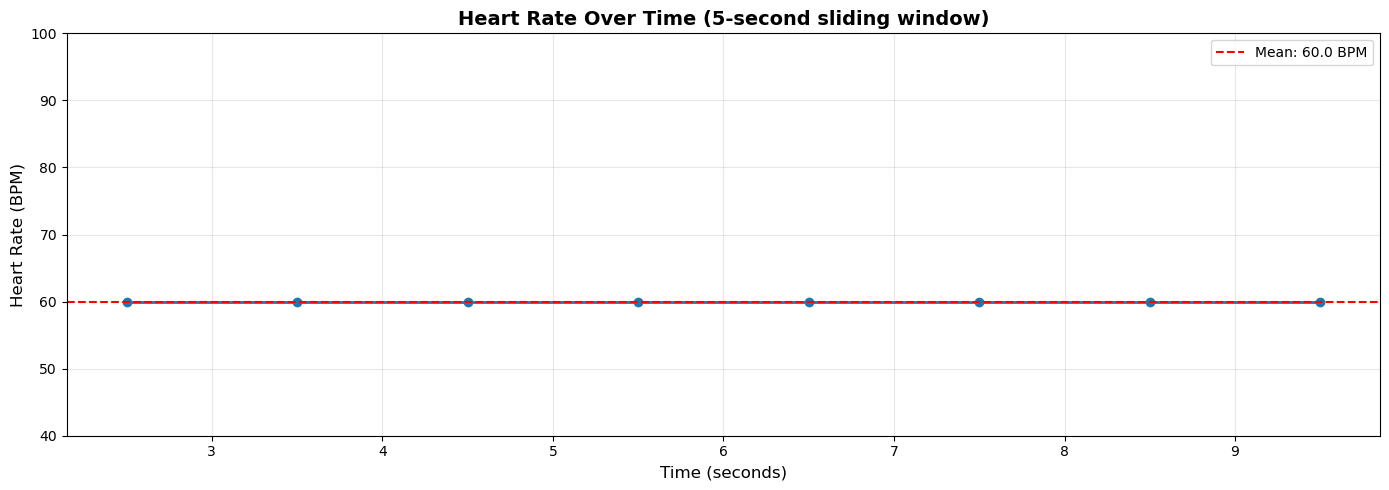

Mean Heart Rate: 60.0 ± 0.0 BPM
Min: 60.0 BPM, Max: 60.0 BPM


In [5]:
# 1. Heart Rate Over Time (Sliding Window)
# This tracks how heart rate changes throughout the video

from scipy.signal import butter, filtfilt
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Reload video for this analysis
video_path = 'IMG_9021.mov'
cap = cv2.VideoCapture(video_path)

R_trace, G_trace, B_trace = [], [], []
while True:
    ret, frame = cap.read()
    if not ret: break
    h, w, _ = frame.shape
    roi = frame[int(h*0.3):int(h*0.7), int(w*0.4):int(w*0.6)]
    avg_color = np.mean(roi, axis=(0, 1))
    B_trace.append(avg_color[0])
    G_trace.append(avg_color[1])
    R_trace.append(avg_color[2])

cap.release()

# Normalize and apply ICA
X_video = np.c_[R_trace, G_trace, B_trace]
X_video = (X_video - np.mean(X_video, axis=0)) / (np.std(X_video, axis=0) + 1e-10)

from sklearn.decomposition import FastICA
ica = FastICA(n_components=3, max_iter=2000, random_state=42)
S_video = ica.fit_transform(X_video)

# Apply bandpass filter
def bandpass_filter(data, lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

fs = 30.0
S_filtered = np.apply_along_axis(lambda x: bandpass_filter(x, 0.7, 4.0, fs), 0, S_video)

# Sliding window heart rate estimation
window_size = int(5 * fs)  # 5-second windows
hop_size = int(1 * fs)  # 1-second hop
hr_over_time = []
time_points = []

for start_idx in range(0, len(S_filtered) - window_size, hop_size):
    window = S_filtered[start_idx:start_idx + window_size, :]
    
    # Find dominant frequency in this window (use component with strongest signal)
    best_hr = 0
    max_power = 0
    
    for comp_idx in range(3):
        fft_val = np.abs(np.fft.rfft(window[:, comp_idx]))
        freqs = np.fft.rfftfreq(len(window), 1/fs)
        freq_mask = (freqs * 60 >= 40) & (freqs * 60 <= 180)
        
        peak_power = np.max(fft_val[freq_mask])
        if peak_power > max_power:
            max_power = peak_power
            peak_idx = np.argmax(fft_val[freq_mask])
            best_hr = freqs[freq_mask][peak_idx] * 60
    
    hr_over_time.append(best_hr)
    time_points.append((start_idx + window_size/2) / fs)

# Plot
plt.figure(figsize=(14, 5))
plt.plot(time_points, hr_over_time, 'o-', linewidth=2, markersize=6)
plt.axhline(y=np.mean(hr_over_time), color='r', linestyle='--', label=f'Mean: {np.mean(hr_over_time):.1f} BPM')
plt.fill_between(time_points, 
                  np.mean(hr_over_time) - np.std(hr_over_time),
                  np.mean(hr_over_time) + np.std(hr_over_time),
                  alpha=0.2, color='red')
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Heart Rate (BPM)', fontsize=12)
plt.title('Heart Rate Over Time (5-second sliding window)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(40, 100)
plt.tight_layout()
plt.show()

print(f"Mean Heart Rate: {np.mean(hr_over_time):.1f} ± {np.std(hr_over_time):.1f} BPM")
print(f"Min: {np.min(hr_over_time):.1f} BPM, Max: {np.max(hr_over_time):.1f} BPM")

### Plot Interpretation: Heart Rate Over Time

The blue line traces the estimated heart rate at each 1-second step. A flat, stable line indicates a consistent heart rate throughout the recording. Variations could be caused by:
- **Natural heart rate variability** (normal physiological variation)
- **Motion artifacts** (head movement during recording)
- **Breathing** (respiratory sinus arrhythmia — HR naturally rises during inhalation)

The red dashed line marks the mean HR, and the shaded area shows the ±1σ confidence band. If most points lie inside the band, the measurement is reliable.

## 2. Individual ICA Components — Time & Frequency Domain

Each ICA component is analyzed in both domains:
- **Time domain** (left): shows the waveform shape — a clean pulse component looks like a quasi-sinusoidal signal
- **Frequency domain** (right): the FFT magnitude spectrum — a strong narrow peak indicates a dominant periodic signal

The **Fourier Transform** decomposes each component into frequency components:

$$X(f) = \int_{-\infty}^{\infty} x(t) \, e^{-j2\pi ft} \, dt$$

In the discrete case (using FFT), the frequency resolution is:

$$\Delta f = \frac{f_s}{N}$$

where $N$ is the number of samples and $f_s$ is the sampling rate. The peak frequency (red dot) indicates the estimated heart rate for that component.

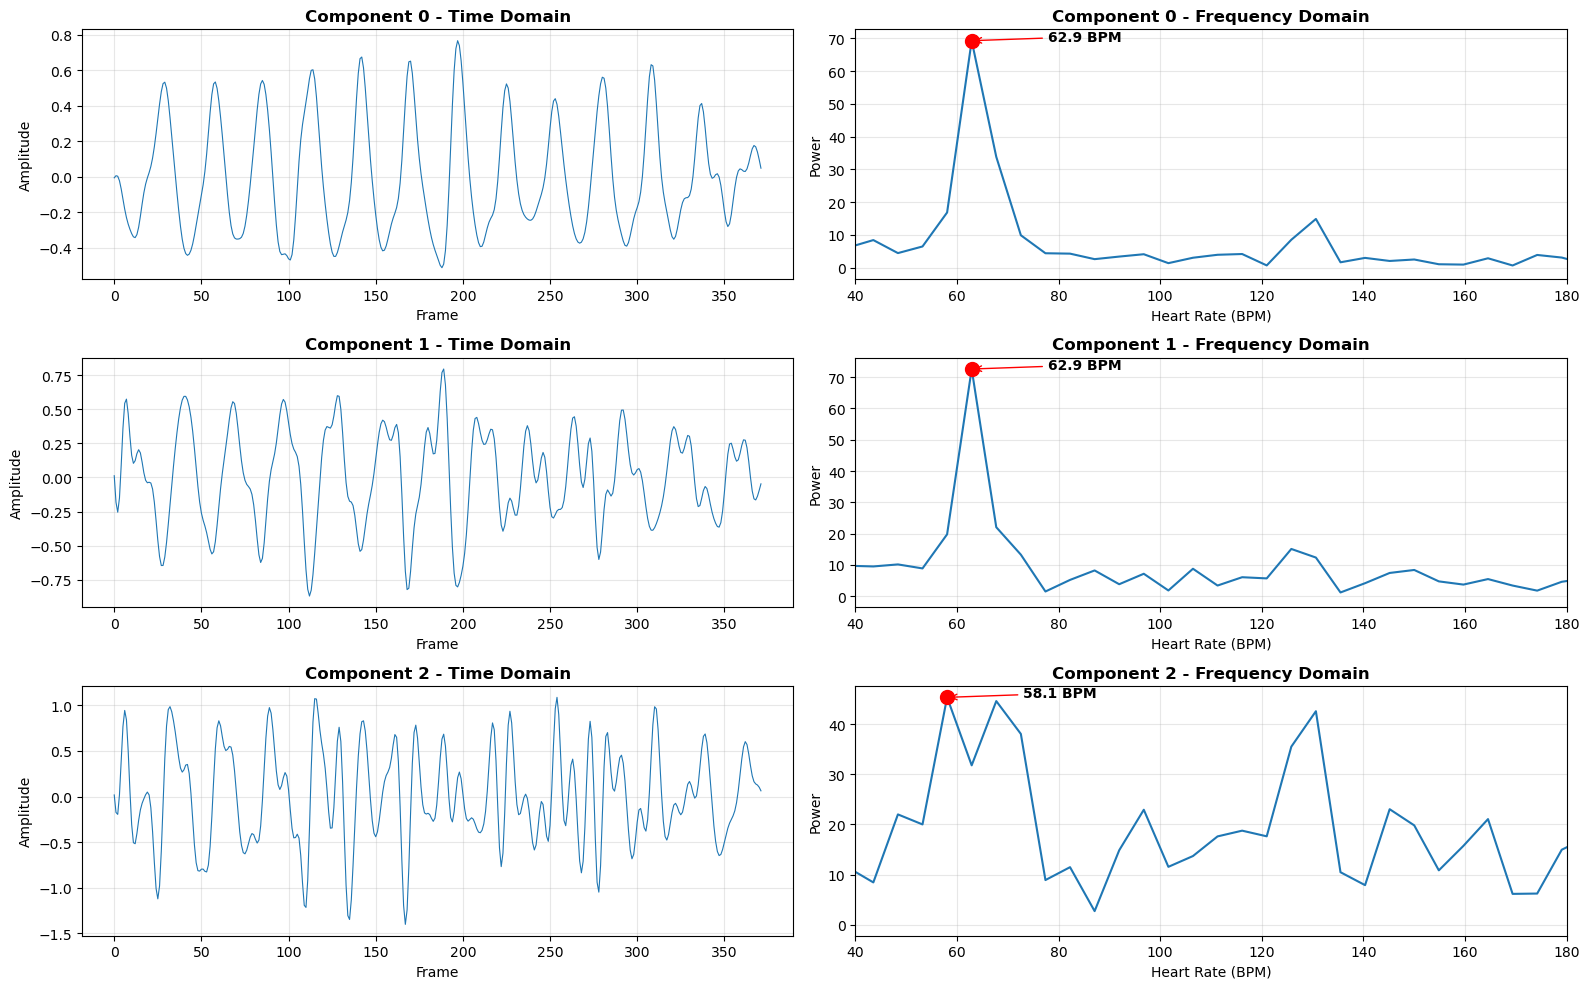

In [6]:
# 2. Individual ICA Components with Frequency Analysis
# Shows each component in both time and frequency domain side-by-side

fig, axes = plt.subplots(3, 2, figsize=(16, 10))

for i in range(3):
    # Time domain (left column)
    axes[i, 0].plot(S_filtered[:, i], linewidth=0.8)
    axes[i, 0].set_title(f'Component {i} - Time Domain', fontweight='bold')
    axes[i, 0].set_xlabel('Frame')
    axes[i, 0].set_ylabel('Amplitude')
    axes[i, 0].grid(True, alpha=0.3)
    
    # Frequency domain (right column)
    fft_val = np.abs(np.fft.rfft(S_filtered[:, i]))
    freqs = np.fft.rfftfreq(len(S_filtered), 1/fs)
    
    axes[i, 1].plot(freqs * 60, fft_val, linewidth=1.5)
    axes[i, 1].set_xlim(40, 180)
    axes[i, 1].set_title(f'Component {i} - Frequency Domain', fontweight='bold')
    axes[i, 1].set_xlabel('Heart Rate (BPM)')
    axes[i, 1].set_ylabel('Power')
    axes[i, 1].grid(True, alpha=0.3)
    
    # Mark the peak
    freq_mask = (freqs * 60 >= 40) & (freqs * 60 <= 180)
    peak_idx = np.argmax(fft_val[freq_mask])
    peak_freq = freqs[freq_mask][peak_idx] * 60
    peak_power = fft_val[freq_mask][peak_idx]
    axes[i, 1].plot(peak_freq, peak_power, 'ro', markersize=10)
    axes[i, 1].annotate(f'{peak_freq:.1f} BPM', 
                         xy=(peak_freq, peak_power),
                         xytext=(peak_freq + 15, peak_power),
                         fontsize=10, fontweight='bold',
                         arrowprops=dict(arrowstyle='->', color='red'))

plt.tight_layout()
plt.show()

### Plot Interpretation: ICA Components

**Left column (Time Domain):** Each row shows one independent component's amplitude over all frames. The component with clear, regular oscillations is the heartbeat signal. Components dominated by slow drifts correspond to lighting changes or slow head movement.

**Right column (Frequency Domain):** The FFT magnitude spectrum with the peak frequency annotated by a red dot and arrow. The component whose peak falls in the 50–90 BPM range with the sharpest peak is the best candidate for the pulse signal. Broad peaks or multiple peaks suggest noise contamination.

## 3. Signal Quality Assessment

This panel provides six diagnostic views to evaluate signal quality:

### 3.1 RGB Channel Correlation
The **Pearson correlation coefficient** between channels $i$ and $j$:

$$\rho_{ij} = \frac{\text{cov}(x_i, x_j)}{\sigma_i \sigma_j}$$

High correlations ($|\rho| \to 1$) between R, G, B are expected because all channels are affected by the same sources. ICA works by finding directions of maximum statistical independence (not just decorrelation).

### 3.2 Filtering Effect
Compares the ICA component before and after bandpass filtering. The filter removes:
- Low frequencies < 0.7 Hz (slow trends, breathing)
- High frequencies > 4.0 Hz (noise, aliasing)

### 3.3 Signal-to-Noise Ratio (SNR)
Computed as:

$$\text{SNR (dB)} = 20 \log_{10} \left( \frac{P_{\text{peak}}}{P_{\text{median}}} \right)$$

where $P_{\text{peak}}$ is the maximum spectral magnitude in the HR range and $P_{\text{median}}$ is the median magnitude. Higher SNR = cleaner signal.

### 3.4 Power Spectral Density (PSD)
PSD shows power per unit frequency on a log scale:

$$S_{xx}(f) = |X(f)|^2 / N$$

Log scale helps visualize the dynamic range of the signal.

### 3.5 RGB Variance Over Time
Rolling variance over 30-frame windows. Stable variance = consistent signal quality. Spikes may indicate motion or lighting changes.

### 3.6 Frequency Peak Confidence
The ratio of peak power to mean power in the HR frequency band. Higher ratios (>3x) indicate a strong, confident heart rate detection.

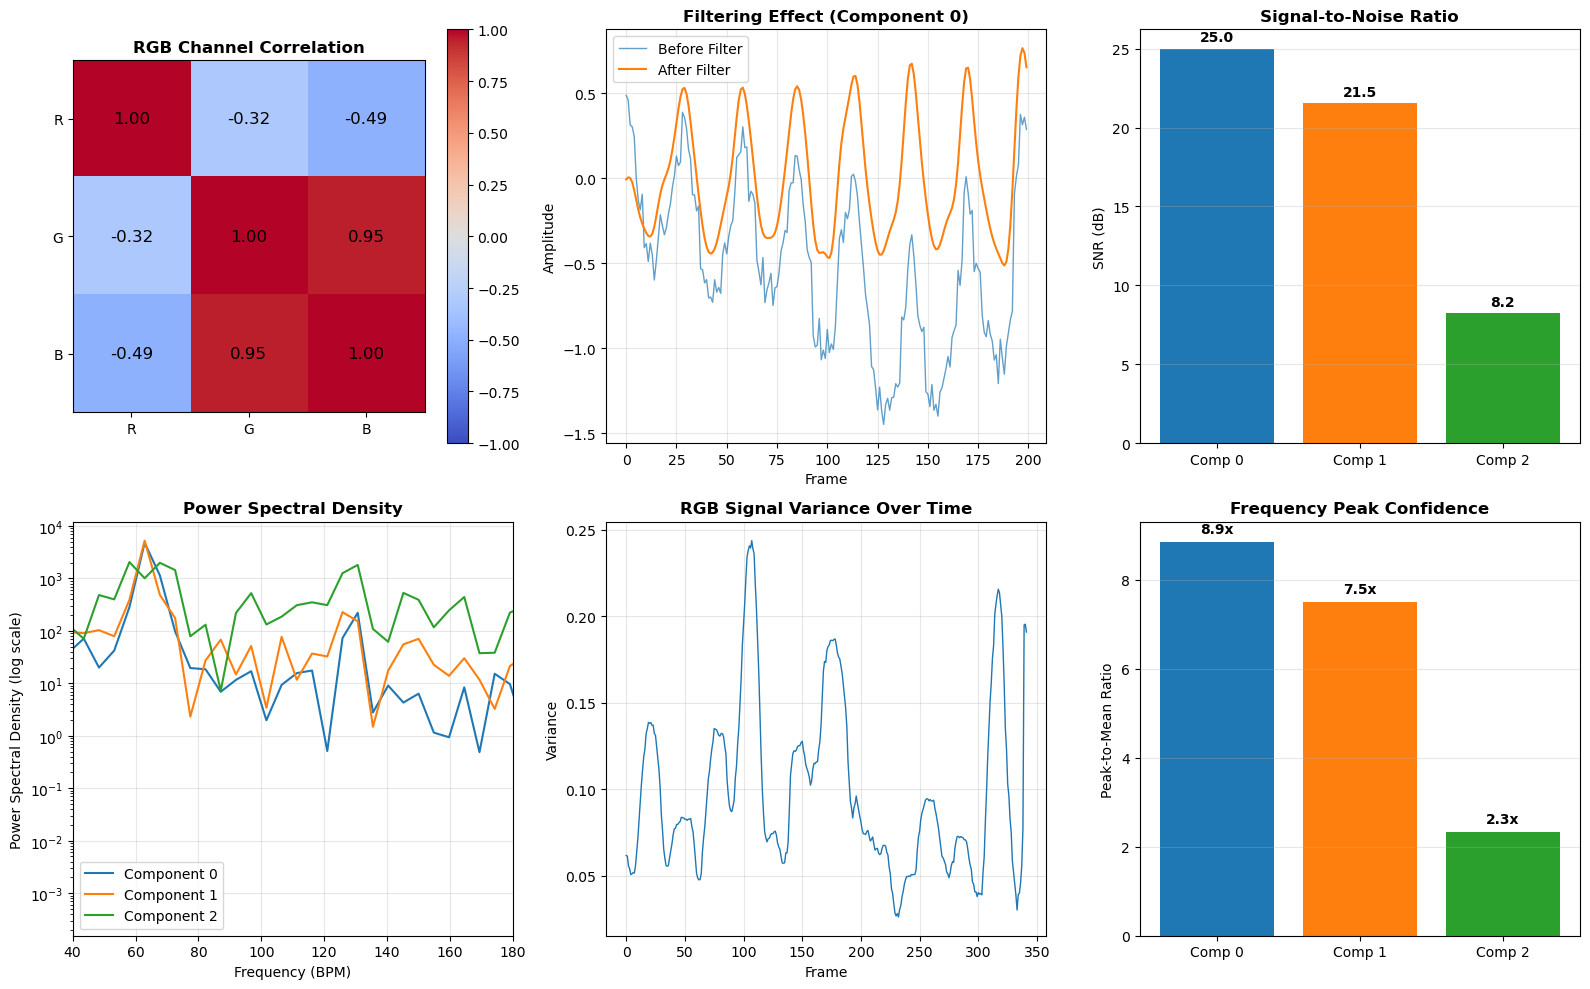

Best Component (highest SNR): Component 0
Best Component (highest Peak Confidence): Component 0


In [7]:
# 3. Signal Quality & Comparison
# Correlation heatmap, before/after filtering, and signal-to-noise ratio

fig = plt.figure(figsize=(16, 10))

# 3.1 Correlation heatmap between RGB channels
ax1 = plt.subplot(2, 3, 1)
corr_matrix = np.corrcoef(X_video.T)
im1 = ax1.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax1.set_xticks([0, 1, 2])
ax1.set_yticks([0, 1, 2])
ax1.set_xticklabels(['R', 'G', 'B'])
ax1.set_yticklabels(['R', 'G', 'B'])
ax1.set_title('RGB Channel Correlation', fontweight='bold')
for i in range(3):
    for j in range(3):
        text = ax1.text(j, i, f'{corr_matrix[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=12)
plt.colorbar(im1, ax=ax1)

# 3.2 Before/After Filtering Comparison (Component 0)
ax2 = plt.subplot(2, 3, 2)
plot_samples = 200
ax2.plot(S_video[:plot_samples, 0], label='Before Filter', alpha=0.7, linewidth=1)
ax2.plot(S_filtered[:plot_samples, 0], label='After Filter', linewidth=1.5)
ax2.set_title('Filtering Effect (Component 0)', fontweight='bold')
ax2.set_xlabel('Frame')
ax2.set_ylabel('Amplitude')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3.3 Signal-to-Noise Ratio for each component
ax3 = plt.subplot(2, 3, 3)
snr_values = []
for i in range(3):
    fft_val = np.abs(np.fft.rfft(S_filtered[:, i]))
    freqs = np.fft.rfftfreq(len(S_filtered), 1/fs)
    freq_mask = (freqs * 60 >= 40) & (freqs * 60 <= 180)
    
    signal_power = np.max(fft_val[freq_mask])
    noise_power = np.median(fft_val[freq_mask])
    snr = 20 * np.log10(signal_power / (noise_power + 1e-10))
    snr_values.append(snr)

bars = ax3.bar([0, 1, 2], snr_values, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax3.set_xticks([0, 1, 2])
ax3.set_xticklabels(['Comp 0', 'Comp 1', 'Comp 2'])
ax3.set_ylabel('SNR (dB)')
ax3.set_title('Signal-to-Noise Ratio', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
for i, (bar, val) in enumerate(zip(bars, snr_values)):
    ax3.text(i, val + 0.5, f'{val:.1f}', ha='center', fontweight='bold')

# 3.4 Power Spectral Density - All Components
ax4 = plt.subplot(2, 3, 4)
for i in range(3):
    fft_val = np.abs(np.fft.rfft(S_filtered[:, i]))
    freqs = np.fft.rfftfreq(len(S_filtered), 1/fs)
    psd = fft_val ** 2
    ax4.semilogy(freqs * 60, psd, label=f'Component {i}', linewidth=1.5)
ax4.set_xlim(40, 180)
ax4.set_xlabel('Frequency (BPM)')
ax4.set_ylabel('Power Spectral Density (log scale)')
ax4.set_title('Power Spectral Density', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 3.5 RGB Variance over time
ax5 = plt.subplot(2, 3, 5)
window = 30
rgb_variance = []
for i in range(len(X_video) - window):
    variance = np.var(np.mean(X_video[i:i+window], axis=1))
    rgb_variance.append(variance)
ax5.plot(rgb_variance, linewidth=1)
ax5.set_xlabel('Frame')
ax5.set_ylabel('Variance')
ax5.set_title('RGB Signal Variance Over Time', fontweight='bold')
ax5.grid(True, alpha=0.3)

# 3.6 Frequency Peak Confidence
ax6 = plt.subplot(2, 3, 6)
peak_ratios = []
for i in range(3):
    fft_val = np.abs(np.fft.rfft(S_filtered[:, i]))
    freqs = np.fft.rfftfreq(len(S_filtered), 1/fs)
    freq_mask = (freqs * 60 >= 40) & (freqs * 60 <= 180)
    
    peak = np.max(fft_val[freq_mask])
    mean = np.mean(fft_val[freq_mask])
    ratio = peak / (mean + 1e-10)
    peak_ratios.append(ratio)

bars = ax6.bar([0, 1, 2], peak_ratios, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax6.set_xticks([0, 1, 2])
ax6.set_xticklabels(['Comp 0', 'Comp 1', 'Comp 2'])
ax6.set_ylabel('Peak-to-Mean Ratio')
ax6.set_title('Frequency Peak Confidence', fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')
for i, (bar, val) in enumerate(zip(bars, peak_ratios)):
    ax6.text(i, val + 0.2, f'{val:.1f}x', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Best Component (highest SNR): Component {np.argmax(snr_values)}")
print(f"Best Component (highest Peak Confidence): Component {np.argmax(peak_ratios)}")

### Plot Interpretation: Signal Quality

**Correlation Heatmap:** The diagonal is always 1.0. Off-diagonal values close to 1 indicate the RGB channels are highly correlated — this is typical because ambient lighting and skin reflection affect all channels similarly. The pulse signal introduces subtle differential changes, especially in the Green channel.

**Filtering Effect:** The thin line (before) shows both low-frequency drift and high-frequency noise. The thick line (after) retains only the heart-rate band, revealing the periodic pulse waveform more clearly.

**SNR Bar Chart:** The component with the highest SNR is the strongest candidate for the pulse signal. SNR values above 15 dB typically indicate reliable detection.

**Power Spectral Density:** Log-scale view showing how power is distributed across frequencies. A sharp narrow peak rising well above the noise floor indicates a clean periodic signal.

**RGB Variance:** Should be relatively stable. Large spikes indicate periods where the signal was disrupted (e.g., head movement), which degrades pulse detection accuracy.

**Peak Confidence:** Ratios above 3–4x indicate the peak is well-separated from background noise. The component with the highest ratio provides the most reliable HR estimate.

## 4. Region of Interest (ROI) Visualization

The ROI defines which pixels are averaged to produce the RGB time series. We use a central rectangle:
- **Vertical**: rows from 30% to 70% of frame height
- **Horizontal**: columns from 40% to 60% of frame width

This region typically captures the **forehead and cheeks**, which are ideal for pulse detection because:
1. Skin is thinner → blood volume changes are more visible
2. Less hair coverage → cleaner signal
3. Less movement than nose or mouth

The average color for each frame is computed as:

$$\bar{c}(t) = \frac{1}{|ROI|} \sum_{(x,y) \in ROI} I_c(x, y, t)$$

where $c \in \{R, G, B\}$, $(x,y)$ are pixel coordinates, and $I_c$ is the intensity in channel $c$.

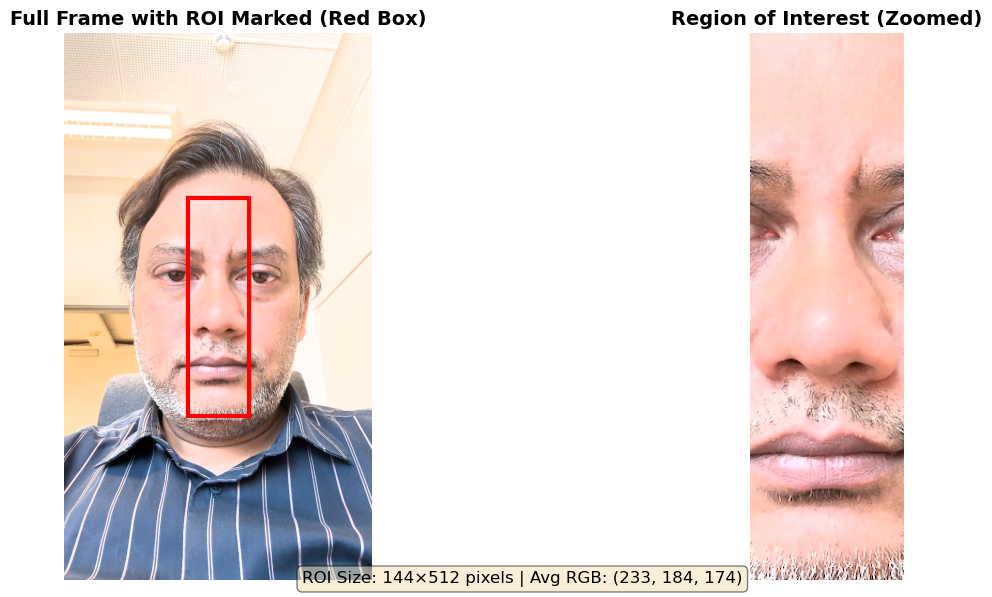

In [8]:
# 4. ROI Visualization
# Shows what region of the video is being analyzed

import cv2
import matplotlib.pyplot as plt

video_path = 'IMG_9021.mov'
cap = cv2.VideoCapture(video_path)

# Get a middle frame
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 2)
ret, frame = cap.read()
cap.release()

if ret:
    # Convert BGR to RGB for proper display
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    h, w = frame_rgb.shape[:2]
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Original frame with ROI marked
    ax1.imshow(frame_rgb)
    roi_box = plt.Rectangle((int(w*0.4), int(h*0.3)), 
                             int(w*0.2), int(h*0.4),
                             linewidth=3, edgecolor='red', facecolor='none')
    ax1.add_patch(roi_box)
    ax1.set_title('Full Frame with ROI Marked (Red Box)', fontsize=14, fontweight='bold')
    ax1.axis('off')
    
    # Zoomed ROI
    roi = frame_rgb[int(h*0.3):int(h*0.7), int(w*0.4):int(w*0.6)]
    ax2.imshow(roi)
    ax2.set_title('Region of Interest (Zoomed)', fontsize=14, fontweight='bold')
    ax2.axis('off')
    
    # Add text with average color
    avg_color = np.mean(roi, axis=(0, 1))
    fig.text(0.5, 0.02, 
             f'ROI Size: {roi.shape[1]}×{roi.shape[0]} pixels | '
             f'Avg RGB: ({avg_color[0]:.0f}, {avg_color[1]:.0f}, {avg_color[2]:.0f})',
             ha='center', fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
else:
    print("Error: Could not read frame from video")

### Plot Interpretation: ROI Visualization

**Left panel:** The full video frame with the ROI marked as a red rectangle. This shows exactly which region of your face is being analyzed. Ideally, the ROI should cover skin areas with good blood flow (forehead, cheeks).

**Right panel:** A zoomed view of the ROI. The average RGB values are printed at the bottom. Typical skin tones will have R > G > B values. If the ROI contains mostly non-skin pixels (e.g., background, hair), the pulse detection will be poor. You may want to adjust the ROI percentages if the box misses your face.

## 5. Spectrogram — Time-Frequency Analysis

The **Short-Time Fourier Transform (STFT)** provides a 2D representation: frequency content as a function of time.

$$\text{STFT}\{x(t)\}(\tau, f) = \int x(t) \cdot w(t - \tau) \cdot e^{-j2\pi ft} \, dt$$

where $w(t)$ is a window function (Hann window). The spectrogram is the squared magnitude:

$$S(\tau, f) = |\text{STFT}\{x(t)\}(\tau, f)|^2$$

Displayed in **decibels (dB)**:

$$S_{\text{dB}} = 10 \log_{10}(S + \epsilon)$$

where $\epsilon = 10^{-10}$ prevents $\log(0)$.

**Parameters used:**
- Segment length (`nperseg`): 93 frames ≈ 3.1 seconds
- Overlap: 46 frames ≈ 1.55 seconds
- Frequency range: 40–180 BPM

The red dots trace the dominant frequency at each time slice. A horizontal line of dots means stable heart rate.

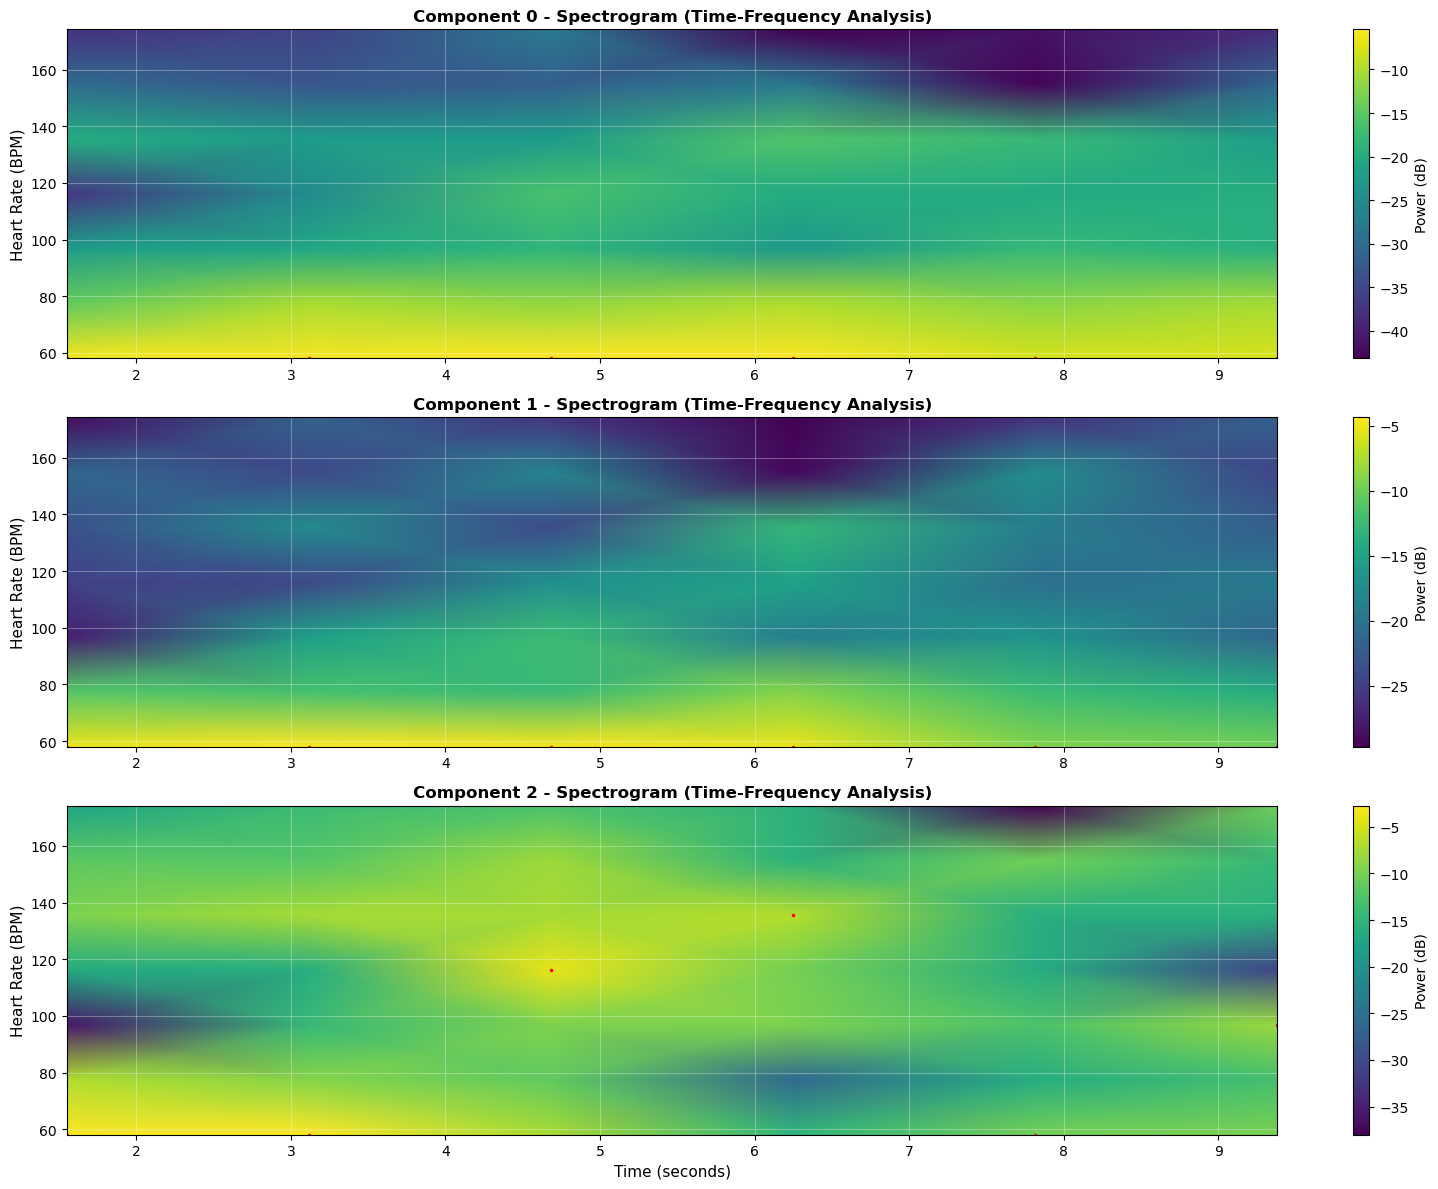

The red dots trace the dominant frequency (heart rate) over time.
Consistent horizontal patterns indicate stable heart rate.


In [9]:
# 5. Spectrogram (Time-Frequency Analysis)
# Shows how frequency content changes over time

from scipy import signal
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for i in range(3):
    # Compute spectrogram
    f, t, Sxx = signal.spectrogram(S_filtered[:, i], fs=fs, 
                                    nperseg=min(256, len(S_filtered)//4),
                                    noverlap=min(128, len(S_filtered)//8))
    
    # Convert frequency to BPM
    f_bpm = f * 60
    
    # Plot only relevant frequency range
    freq_mask = (f_bpm >= 40) & (f_bpm <= 180)
    
    im = axes[i].pcolormesh(t, f_bpm[freq_mask], 10 * np.log10(Sxx[freq_mask, :] + 1e-10),
                            shading='gouraud', cmap='viridis')
    axes[i].set_ylabel('Heart Rate (BPM)', fontsize=11)
    axes[i].set_title(f'Component {i} - Spectrogram (Time-Frequency Analysis)', 
                      fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3, color='white')
    plt.colorbar(im, ax=axes[i], label='Power (dB)')
    
    # Mark dominant frequency over time
    for time_idx in range(len(t)):
        spectrum_slice = Sxx[freq_mask, time_idx]
        if np.max(spectrum_slice) > 0:
            peak_idx = np.argmax(spectrum_slice)
            peak_freq = f_bpm[freq_mask][peak_idx]
            axes[i].plot(t[time_idx], peak_freq, 'r.', markersize=3)

axes[-1].set_xlabel('Time (seconds)', fontsize=11)
plt.tight_layout()
plt.show()

print("The red dots trace the dominant frequency (heart rate) over time.")
print("Consistent horizontal patterns indicate stable heart rate.")

### Plot Interpretation: Spectrograms

Each spectrogram shows one ICA component. The x-axis is time, y-axis is frequency (in BPM), and color intensity represents power (brighter = stronger).

**What to look for:**
- A **bright horizontal band** at a consistent BPM level indicates a stable heart rate throughout the recording
- The component with the brightest, most focused band is the pulse component
- **Vertical streaks** indicate transient broadband noise events (e.g., sudden movement)
- The **red dot trajectory** should form a roughly horizontal line for a clean pulse signal
- Variations in the red dots indicate actual heart rate variability or signal quality fluctuations

## 6. ICA Mixing & Unmixing Matrices

Understanding ICA through its matrices:

### Mixing Matrix $\mathbf{A}$

Describes how the independent components combine to form the observed RGB signals:

$$\begin{bmatrix} R(t) \\ G(t) \\ B(t) \end{bmatrix} = \begin{bmatrix} a_{11} & a_{12} & a_{13} \\ a_{21} & a_{22} & a_{23} \\ a_{31} & a_{32} & a_{33} \end{bmatrix} \begin{bmatrix} s_1(t) \\ s_2(t) \\ s_3(t) \end{bmatrix}$$

A column of $\mathbf{A}$ represents how one source affects all RGB channels. Example: if column $j$ has similar weights for R, G, B → source $j$ affects all channels equally (likely ambient lighting).

### Unmixing Matrix $\mathbf{W} = \mathbf{A}^{-1}$

The inverse operation — from RGB to components:

$$\begin{bmatrix} s_1(t) \\ s_2(t) \\ s_3(t) \end{bmatrix} = \begin{bmatrix} w_{11} & w_{12} & w_{13} \\ w_{21} & w_{22} & w_{23} \\ w_{31} & w_{32} & w_{33} \end{bmatrix} \begin{bmatrix} R(t) \\ G(t) \\ B(t) \end{bmatrix}$$

A row of $\mathbf{W}$ shows how one component is computed from RGB. The pulse component typically has a strong Green weight because hemoglobin absorbs green light most strongly.

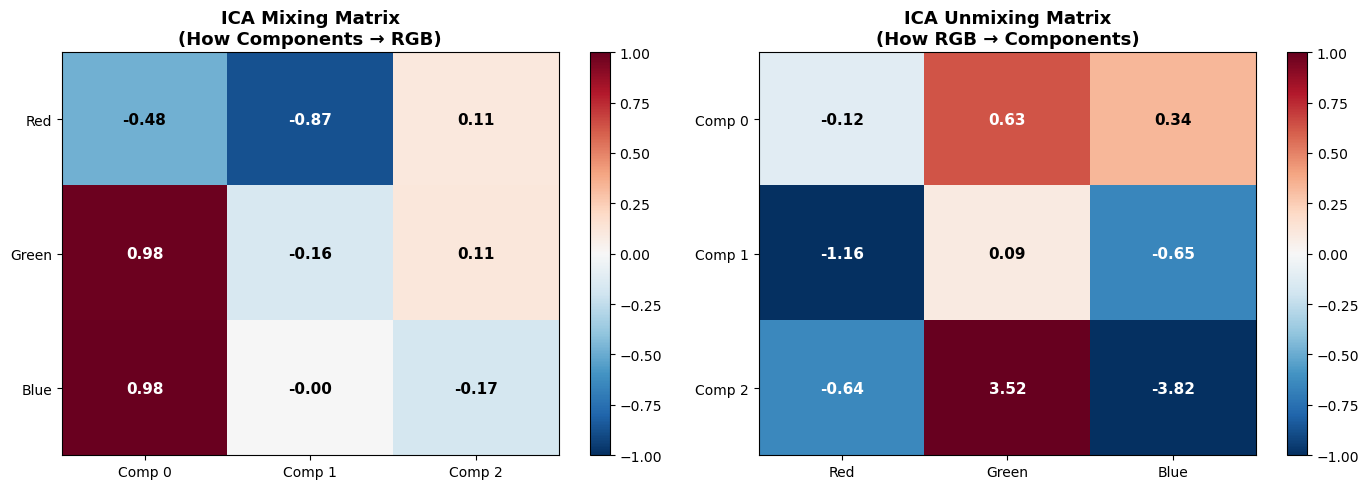

Interpretation:
- Mixing matrix shows the contribution of each component to RGB channels
- Unmixing matrix shows how RGB channels combine to form components
- The component that strongly uses the Green channel is likely the pulse signal


In [10]:
# 6. ICA Mixing Matrix Heatmap
# Shows how RGB channels are mixed to form independent components

mixing_matrix = ica.mixing_  # Shape: (3, 3) - shows how to go from components back to RGB

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Mixing matrix
im1 = ax1.imshow(mixing_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax1.set_xticks([0, 1, 2])
ax1.set_yticks([0, 1, 2])
ax1.set_xticklabels(['Comp 0', 'Comp 1', 'Comp 2'])
ax1.set_yticklabels(['Red', 'Green', 'Blue'])
ax1.set_title('ICA Mixing Matrix\n(How Components → RGB)', fontsize=13, fontweight='bold')

for i in range(3):
    for j in range(3):
        text = ax1.text(j, i, f'{mixing_matrix[i, j]:.2f}',
                       ha="center", va="center", 
                       color="white" if abs(mixing_matrix[i, j]) > 0.5 else "black",
                       fontsize=11, fontweight='bold')
plt.colorbar(im1, ax=ax1)

# Unmixing matrix (inverse)
unmixing_matrix = ica.components_  # Shape: (3, 3) - shows how to go from RGB to components

im2 = ax2.imshow(unmixing_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax2.set_xticks([0, 1, 2])
ax2.set_yticks([0, 1, 2])
ax2.set_xticklabels(['Red', 'Green', 'Blue'])
ax2.set_yticklabels(['Comp 0', 'Comp 1', 'Comp 2'])
ax2.set_title('ICA Unmixing Matrix\n(How RGB → Components)', fontsize=13, fontweight='bold')

for i in range(3):
    for j in range(3):
        text = ax2.text(j, i, f'{unmixing_matrix[i, j]:.2f}',
                       ha="center", va="center", 
                       color="white" if abs(unmixing_matrix[i, j]) > 0.5 else "black",
                       fontsize=11, fontweight='bold')
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Mixing matrix shows the contribution of each component to RGB channels")
print("- Unmixing matrix shows how RGB channels combine to form components")
print("- The component that strongly uses the Green channel is likely the pulse signal")

### Plot Interpretation: Mixing & Unmixing Matrices

**Left heatmap (Mixing Matrix):** Each column represents one independent component. Reading down a column shows how that source contributes to R, G, and B. If a column has roughly equal weights → it's likely ambient lighting. If a column has a strong Green weight and weaker R/B → it's likely the pulse signal (hemoglobin absorption is strongest in green wavelengths).

**Right heatmap (Unmixing Matrix):** Each row shows the linear combination of RGB channels used to extract one component. The row corresponding to the pulse component should emphasize the Green channel and potentially use Red/Blue in a contrasting way to cancel common-mode noise.

**Color scale:** Values near 0 (white) mean little contribution. Positive (red) and negative (blue) values indicate the direction and strength of contribution.

## 7. 3D Phase Space Trajectory

The phase space plot visualizes the multivariate signal as a trajectory in 3D. Each point represents one time sample, colored by time (frame number).

For the RGB space, point $(R(t), G(t), B(t))$ traces a path as the color changes over time. The shape of this trajectory reveals the data structure:

- **Random cloud**: noisy, no structure → poor signal
- **Elongated ellipsoid**: correlated channels → pre-ICA data
- **Circular/helical pattern**: periodic signal → heartbeat

After ICA transformation, the axes become statistically independent. After filtering, only the heart-rate band remains, and the trajectory should show more circular patterns if a periodic pulse is present.

**State-space representation:**

$$\mathbf{p}(t) = \begin{bmatrix} s_1(t) \\ s_2(t) \\ s_3(t) \end{bmatrix}$$

The trajectory $\{\mathbf{p}(t)\}_{t=1}^{N}$ in 3D reveals the dynamics of the three independent sources simultaneously.

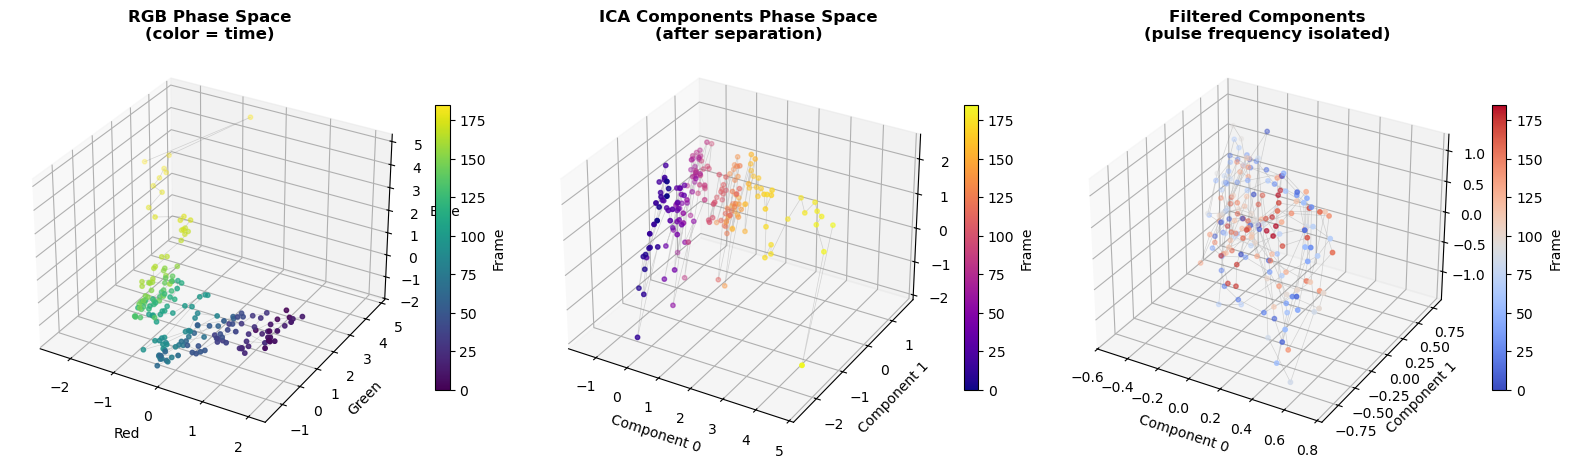

The trajectory shows how the signal evolves in 3D space over time.
Circular/periodic patterns indicate rhythmic signals (like heartbeat).


In [11]:
# 7. 3D Phase Space Plot
# Visualize RGB trajectory in 3D space

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 6))

# 7.1 Raw RGB trajectory
ax1 = fig.add_subplot(131, projection='3d')
# Use a subset for clarity
subset = slice(0, min(500, len(X_video)), 2)
scatter = ax1.scatter(X_video[subset, 0], X_video[subset, 1], X_video[subset, 2],
                      c=np.arange(len(X_video[subset])), cmap='viridis', s=10)
ax1.plot(X_video[subset, 0], X_video[subset, 1], X_video[subset, 2], 
         'gray', alpha=0.3, linewidth=0.5)
ax1.set_xlabel('Red', fontsize=10)
ax1.set_ylabel('Green', fontsize=10)
ax1.set_zlabel('Blue', fontsize=10)
ax1.set_title('RGB Phase Space\n(color = time)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax1, label='Frame', shrink=0.5)

# 7.2 ICA Components trajectory
ax2 = fig.add_subplot(132, projection='3d')
scatter2 = ax2.scatter(S_video[subset, 0], S_video[subset, 1], S_video[subset, 2],
                       c=np.arange(len(S_video[subset])), cmap='plasma', s=10)
ax2.plot(S_video[subset, 0], S_video[subset, 1], S_video[subset, 2], 
         'gray', alpha=0.3, linewidth=0.5)
ax2.set_xlabel('Component 0', fontsize=10)
ax2.set_ylabel('Component 1', fontsize=10)
ax2.set_zlabel('Component 2', fontsize=10)
ax2.set_title('ICA Components Phase Space\n(after separation)', fontsize=12, fontweight='bold')
plt.colorbar(scatter2, ax=ax2, label='Frame', shrink=0.5)

# 7.3 Filtered Components trajectory
ax3 = fig.add_subplot(133, projection='3d')
scatter3 = ax3.scatter(S_filtered[subset, 0], S_filtered[subset, 1], S_filtered[subset, 2],
                       c=np.arange(len(S_filtered[subset])), cmap='coolwarm', s=10)
ax3.plot(S_filtered[subset, 0], S_filtered[subset, 1], S_filtered[subset, 2], 
         'gray', alpha=0.3, linewidth=0.5)
ax3.set_xlabel('Component 0', fontsize=10)
ax3.set_ylabel('Component 1', fontsize=10)
ax3.set_zlabel('Component 2', fontsize=10)
ax3.set_title('Filtered Components\n(pulse frequency isolated)', fontsize=12, fontweight='bold')
plt.colorbar(scatter3, ax=ax3, label='Frame', shrink=0.5)

plt.tight_layout()
plt.show()

print("The trajectory shows how the signal evolves in 3D space over time.")
print("Circular/periodic patterns indicate rhythmic signals (like heartbeat).")

### Plot Interpretation: 3D Phase Space

**Left (RGB Phase Space):** The raw RGB trajectory shows an elongated, correlated structure — all three channels move together because they share common sources. The color gradient (dark to bright) shows temporal evolution.

**Middle (ICA Phase Space):** After ICA separation, the trajectory is more spread across all three axes, confirming the components are statistically independent. The structure is more complex because each axis now represents a different source.

**Right (Filtered Phase Space):** After bandpass filtering, only frequencies in the heart rate range remain. If a strong pulse signal exists, you should see more circular/periodic patterns in the trajectory as the dominant oscillation traces out loops in the 3D space.

## 8. Power Spectral Density with Harmonics

A periodic signal (like a heartbeat) produces not just the **fundamental frequency** $f_0$ but also **harmonics** at integer multiples:

$$f_n = n \cdot f_0, \quad n = 1, 2, 3, \ldots$$

For a heart rate of ~63 BPM ($f_0 = 1.05$ Hz):
- **Fundamental** ($f_1$): 63 BPM
- **2nd harmonic** ($f_2$): 126 BPM
- **3rd harmonic** ($f_3$): 189 BPM

The **Power Spectral Density (PSD)** is computed as:

$$S_{xx}[k] = \frac{|X[k]|^2}{N}$$

where $X[k]$ is the DFT coefficient at index $k$, and $N$ is the total number of samples.

**Why harmonics matter:** A pure sinusoid has only a fundamental. A real heartbeat pulse is not perfectly sinusoidal — it has a sharp systolic peak followed by a slower diastolic decay. This asymmetry generates harmonics. Strong harmonics relative to the fundamental confirm a clean, repeating biological signal rather than random noise.

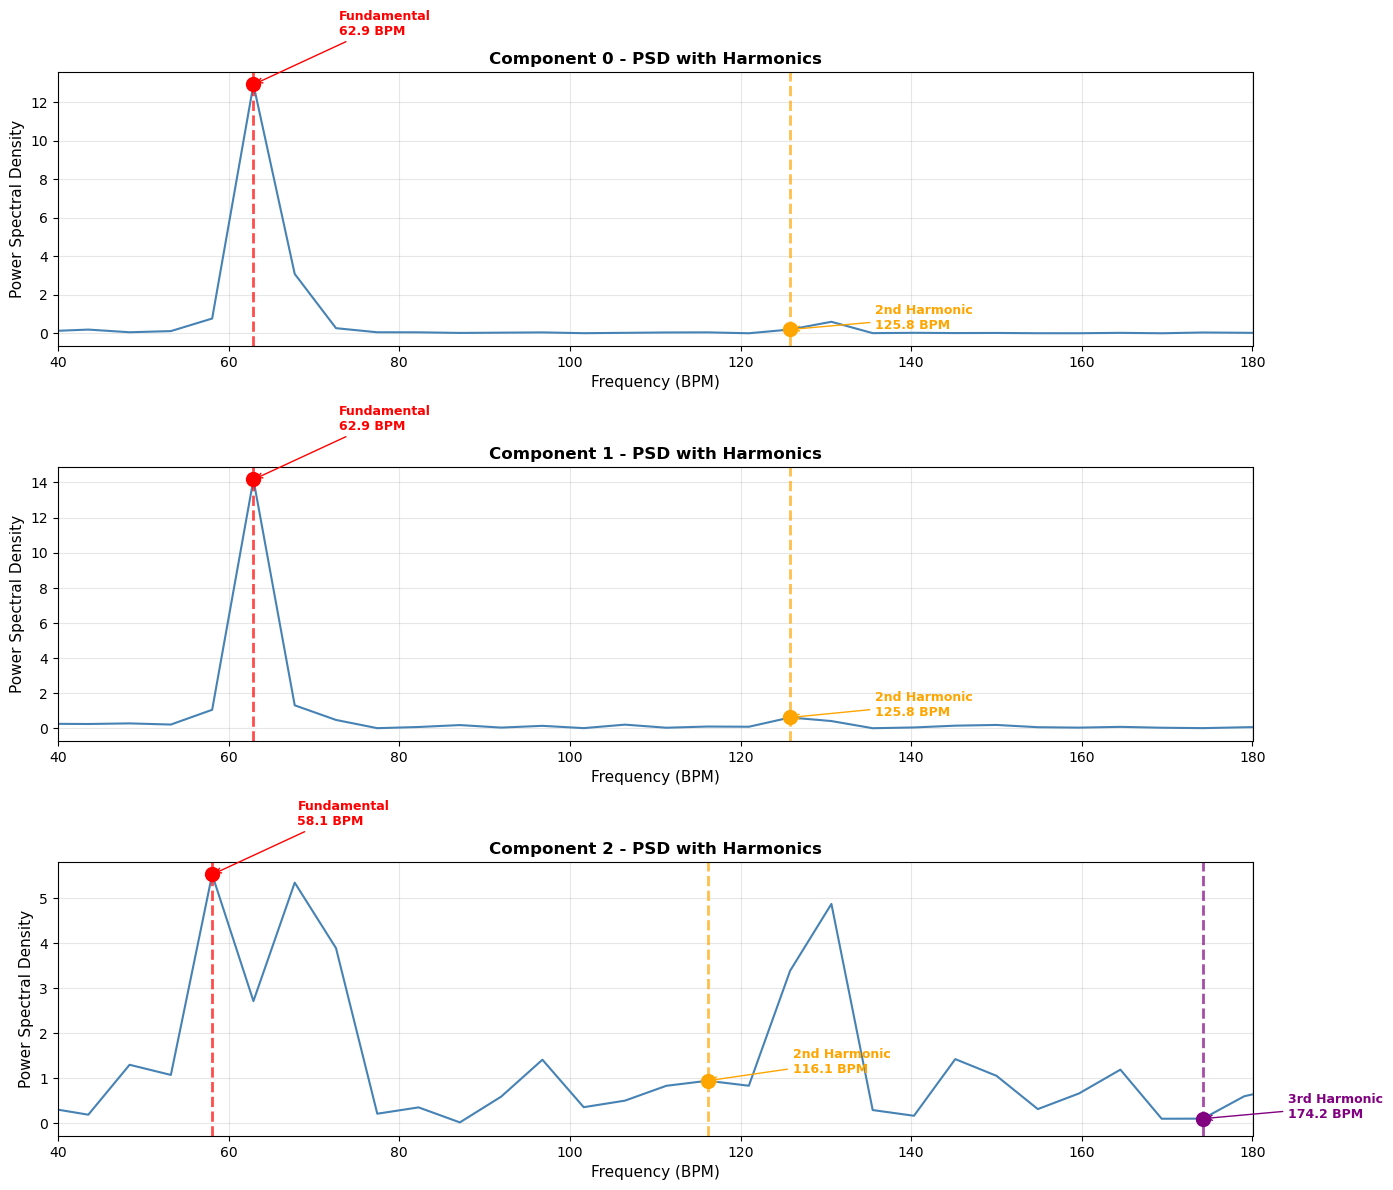

Fundamental frequency (heart rate): 58.1 BPM
Harmonics are multiples of the fundamental frequency.
Strong harmonics indicate a clean, periodic signal.


In [12]:
# 8. Power Spectral Density with Harmonics
# Shows fundamental frequency and harmonics (2x, 3x)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for i in range(3):
    fft_val = np.abs(np.fft.rfft(S_filtered[:, i]))
    freqs = np.fft.rfftfreq(len(S_filtered), 1/fs)
    psd = fft_val ** 2 / len(S_filtered)
    
    # Plot PSD
    axes[i].plot(freqs * 60, psd, linewidth=1.5, color='steelblue')
    axes[i].set_xlim(40, 180)
    axes[i].set_xlabel('Frequency (BPM)', fontsize=11)
    axes[i].set_ylabel('Power Spectral Density', fontsize=11)
    axes[i].set_title(f'Component {i} - PSD with Harmonics', fontsize=12, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    
    # Find fundamental frequency
    freq_mask = (freqs * 60 >= 40) & (freqs * 60 <= 180)
    peak_idx = np.argmax(psd[freq_mask])
    fundamental = freqs[freq_mask][peak_idx] * 60
    
    # Mark fundamental and harmonics
    harmonics = [1, 2, 3]
    colors = ['red', 'orange', 'purple']
    labels = ['Fundamental', '2nd Harmonic', '3rd Harmonic']
    
    for harm, color, label in zip(harmonics, colors, labels):
        harm_freq = fundamental * harm
        if harm_freq <= 180:
            axes[i].axvline(harm_freq, color=color, linestyle='--', linewidth=2, alpha=0.7)
            
            # Find power at this frequency
            freq_idx = np.argmin(np.abs(freqs * 60 - harm_freq))
            power_at_harm = psd[freq_idx]
            
            axes[i].plot(harm_freq, power_at_harm, 'o', color=color, markersize=10)
            axes[i].annotate(f'{label}\n{harm_freq:.1f} BPM', 
                           xy=(harm_freq, power_at_harm),
                           xytext=(harm_freq + 10, power_at_harm * 1.2),
                           fontsize=9, color=color, fontweight='bold',
                           arrowprops=dict(arrowstyle='->', color=color))

plt.tight_layout()
plt.show()

print(f"Fundamental frequency (heart rate): {fundamental:.1f} BPM")
print("Harmonics are multiples of the fundamental frequency.")
print("Strong harmonics indicate a clean, periodic signal.")

### Plot Interpretation: PSD with Harmonics

Each subplot shows one component's PSD. The **red dashed line** marks the fundamental frequency (heart rate), **orange** marks the 2nd harmonic (2×HR), and **purple** marks the 3rd harmonic (3×HR).

**What to look for:**
- A strong peak at the fundamental confirms a consistent oscillation at that frequency
- Visible 2nd and 3rd harmonics confirm the signal is truly periodic (not just noise that happened to peak there)
- If harmonics are absent, the signal may be more sinusoidal (still valid) or the peak might be noise
- The component with the strongest fundamental-to-noise ratio provides the best heart rate estimate

## 9. Heart Rate Variability (HRV) Analysis

HRV quantifies the variation in time between successive heartbeats. It's an important marker of autonomic nervous system function.

### Peak Detection

Individual heartbeats are detected as peaks in the best ICA component using `scipy.signal.find_peaks` with:
- **Minimum distance**: 70% of the expected inter-beat interval (to avoid double-counting)
- **Prominence threshold**: $0.5 \sigma$ (peaks must stand out from background)

### Inter-Beat Interval (IBI)

$$\text{IBI}_i = (t_{\text{peak}_{i+1}} - t_{\text{peak}_i}) \times \frac{1000}{f_s} \quad \text{(in ms)}$$

### Key HRV Metrics

**SDNN** — Standard Deviation of all Normal-to-Normal (NN) intervals:

$$\text{SDNN} = \sqrt{\frac{1}{N-1} \sum_{i=1}^{N} (\text{IBI}_i - \overline{\text{IBI}})^2}$$

Higher SDNN indicates greater sympathovagal balance. Typical values: 50–100 ms for healthy adults.

**RMSSD** — Root Mean Square of Successive Differences:

$$\text{RMSSD} = \sqrt{\frac{1}{N-1} \sum_{i=1}^{N-1} (\text{IBI}_{i+1} - \text{IBI}_i)^2}$$

RMSSD reflects short-term (beat-to-beat) variability, primarily parasympathetic (vagal) activity.

### Poincaré Plot

Plots $\text{IBI}(n+1)$ vs $\text{IBI}(n)$. The scatter pattern reveals:
- **Tight cluster on the diagonal**: very regular rhythm (low variability)
- **Elongated along the diagonal** (SD2): long-term variability
- **Spread perpendicular to diagonal** (SD1): short-term variability
- The identity line ($y = x$) represents perfectly constant inter-beat intervals

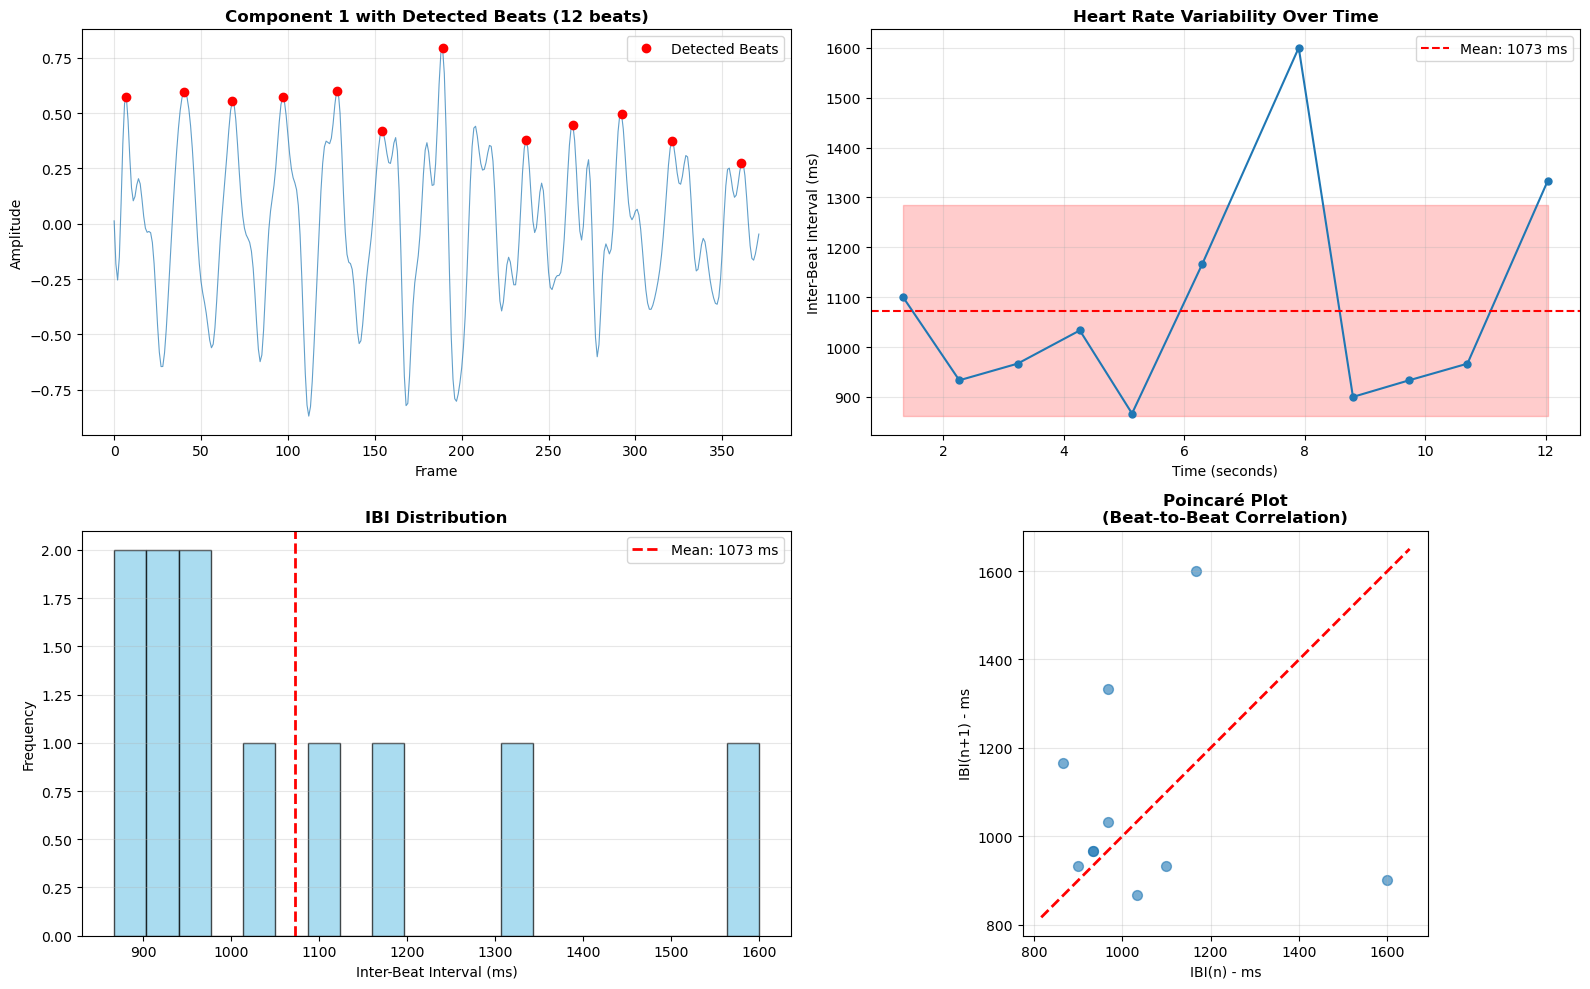


=== Heart Rate Variability Metrics ===
Total beats detected: 12
Mean Heart Rate: 55.9 BPM
Mean IBI: 1072.7 ms
SDNN (HRV): 211.2 ms
RMSSD: 310.7 ms
Min IBI: 866.7 ms, Max IBI: 1600.0 ms

Interpretation:
- Higher HRV (SDNN) generally indicates better cardiovascular health
- RMSSD reflects short-term variability (parasympathetic activity)
- Poincaré plot: points close to diagonal = consistent rhythm


In [14]:
# 9. Heart Rate Variability (HRV)
# Analyzes beat-to-beat intervals and their variation

from scipy.signal import find_peaks

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Find the best component (highest peak in frequency domain)
peak_powers = []
for i in range(3):
    fft_val = np.abs(np.fft.rfft(S_filtered[:, i]))
    freqs = np.fft.rfftfreq(len(S_filtered), 1/fs)
    freq_mask = (freqs * 60 >= 40) & (freqs * 60 <= 180)
    peak_powers.append(np.max(fft_val[freq_mask]))

best_component = np.argmax(peak_powers)
signal_to_analyze = S_filtered[:, best_component]

# Find peaks in the signal (each peak = one heartbeat)
# Estimate expected distance between peaks
fft_val = np.abs(np.fft.rfft(signal_to_analyze))
freqs = np.fft.rfftfreq(len(signal_to_analyze), 1/fs)
freq_mask = (freqs * 60 >= 40) & (freqs * 60 <= 180)
dominant_freq_hz = freqs[freq_mask][np.argmax(fft_val[freq_mask])]
expected_distance = fs / dominant_freq_hz * 0.7  # 70% of expected period

peaks, properties = find_peaks(signal_to_analyze, 
                                distance=expected_distance,
                                prominence=np.std(signal_to_analyze) * 0.5)

# Calculate inter-beat intervals (IBI) in milliseconds
ibi = np.diff(peaks) / fs * 1000
time_of_beats = peaks[1:] / fs

# 9.1 Signal with detected peaks
axes[0, 0].plot(signal_to_analyze, linewidth=0.8, alpha=0.7)
axes[0, 0].plot(peaks, signal_to_analyze[peaks], 'ro', markersize=6, label='Detected Beats')
axes[0, 0].set_xlabel('Frame')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].set_title(f'Component {best_component} with Detected Beats ({len(peaks)} beats)', 
                     fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 9.2 Inter-beat intervals over time
axes[0, 1].plot(time_of_beats, ibi, 'o-', markersize=5, linewidth=1.5)
axes[0, 1].axhline(y=np.mean(ibi), color='r', linestyle='--', 
                   label=f'Mean: {np.mean(ibi):.0f} ms')
axes[0, 1].fill_between(time_of_beats,
                        np.mean(ibi) - np.std(ibi),
                        np.mean(ibi) + np.std(ibi),
                        alpha=0.2, color='red')
axes[0, 1].set_xlabel('Time (seconds)')
axes[0, 1].set_ylabel('Inter-Beat Interval (ms)')
axes[0, 1].set_title('Heart Rate Variability Over Time', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 9.3 IBI histogram
axes[1, 0].hist(ibi, bins=20, edgecolor='black', alpha=0.7, color='skyblue')
axes[1, 0].axvline(np.mean(ibi), color='r', linestyle='--', linewidth=2,
                   label=f'Mean: {np.mean(ibi):.0f} ms')
axes[1, 0].set_xlabel('Inter-Beat Interval (ms)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('IBI Distribution', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 9.4 Poincaré plot (IBI_n vs IBI_n+1)
axes[1, 1].scatter(ibi[:-1], ibi[1:], alpha=0.6, s=50)
min_val = np.min(ibi) - 50
max_val = np.max(ibi) + 50
axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[1, 1].set_xlabel('IBI(n) - ms')
axes[1, 1].set_ylabel('IBI(n+1) - ms')
axes[1, 1].set_title('Poincaré Plot\n(Beat-to-Beat Correlation)', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_aspect('equal')

plt.tight_layout()
plt.show()

# HRV metrics
sdnn = np.std(ibi)  # Standard deviation of IBI
rmssd = np.sqrt(np.mean(np.diff(ibi)**2))  # Root mean square of successive differences
mean_hr = 60000 / np.mean(ibi)  # Convert IBI to BPM

print("\n=== Heart Rate Variability Metrics ===")
print(f"Total beats detected: {len(peaks)}")
print(f"Mean Heart Rate: {mean_hr:.1f} BPM")
print(f"Mean IBI: {np.mean(ibi):.1f} ms")
print(f"SDNN (HRV): {sdnn:.1f} ms")
print(f"RMSSD: {rmssd:.1f} ms")
print(f"Min IBI: {np.min(ibi):.1f} ms, Max IBI: {np.max(ibi):.1f} ms")
print("\nInterpretation:")
print("- Higher HRV (SDNN) generally indicates better cardiovascular health")
print("- RMSSD reflects short-term variability (parasympathetic activity)")
print("- Poincaré plot: points close to diagonal = consistent rhythm")

### Plot Interpretation: Heart Rate Variability

**Top-left (Signal with Detected Beats):** The filtered ICA component with red dots marking each detected heartbeat. You should see regular spacing between peaks. Missing or extra peaks can skew HRV metrics.

**Top-right (IBI Over Time):** Each point shows the time gap (in ms) between consecutive beats. The red dashed line is the mean IBI, and the shaded band is ±1σ. A gently fluctuating line is normal — this is the "variability" we're measuring. Sharp jumps may indicate detection errors.

**Bottom-left (IBI Histogram):** Shows the distribution of inter-beat intervals. A roughly Gaussian (bell-shaped) distribution centered around the mean is expected. Multiple modes (peaks) could indicate detection artifacts.

**Bottom-right (Poincaré Plot):** Each point represents two consecutive IBIs plotted against each other. Points clustered tightly on the identity line (red dashed) indicate a very regular rhythm. More scatter = more variability. The shape of the cloud:
- Elongated along the diagonal → long-term trending
- Spread perpendicular to diagonal → beat-to-beat variability

**Reported Metrics:**
- **Mean HR**: overall average heart rate converted from IBI
- **SDNN**: total variability (> 50 ms is healthy for short recordings)
- **RMSSD**: short-term variability, reflecting parasympathetic tone

## 10. Automated Component Selection Score

Not all ICA components contain the pulse signal. This automated scoring system evaluates each component across five criteria to determine which is most likely the heartbeat.

### Scoring Criteria

| Criterion | Weight | Description |
|-----------|--------|-------------|
| Peak Sharpness | 25% | $\frac{P_{\text{peak}}}{P_{\text{mean}}} / 10$ — How pronounced is the spectral peak |
| Frequency Range | 20% | Is the peak in resting HR range (50–90 BPM)? |
| SNR | 25% | $\frac{20 \log_{10}(P_\text{peak} / P_{25\%})}{30}$ — Signal quality |
| Consistency | 15% | $1 - \frac{\sigma(\text{var}_w)}{\mu(\text{var}_w)}$ — Stability over time |
| Spectral Purity | 15% | $1 - \frac{H(S)}{H_{\max}}$ — How concentrated the power is |

### Spectral Entropy

Measures how spread out the spectral energy is:

$$H(S) = -\sum_k \hat{S}[k] \log_2 \hat{S}[k]$$

where $\hat{S}[k] = \frac{|X[k]|}{\sum_j |X[j]|}$ is the normalized spectrum. Low entropy = energy concentrated at one frequency = pure tone = likely heartbeat. Maximum entropy = uniform spectrum = noise.

### Total Score

$$\text{Score}_i = \sum_{c} w_c \cdot s_{i,c}$$

where $w_c$ is the weight and $s_{i,c}$ is the score (0–100) for criterion $c$ and component $i$. The component with the highest total score is selected as the pulse signal.

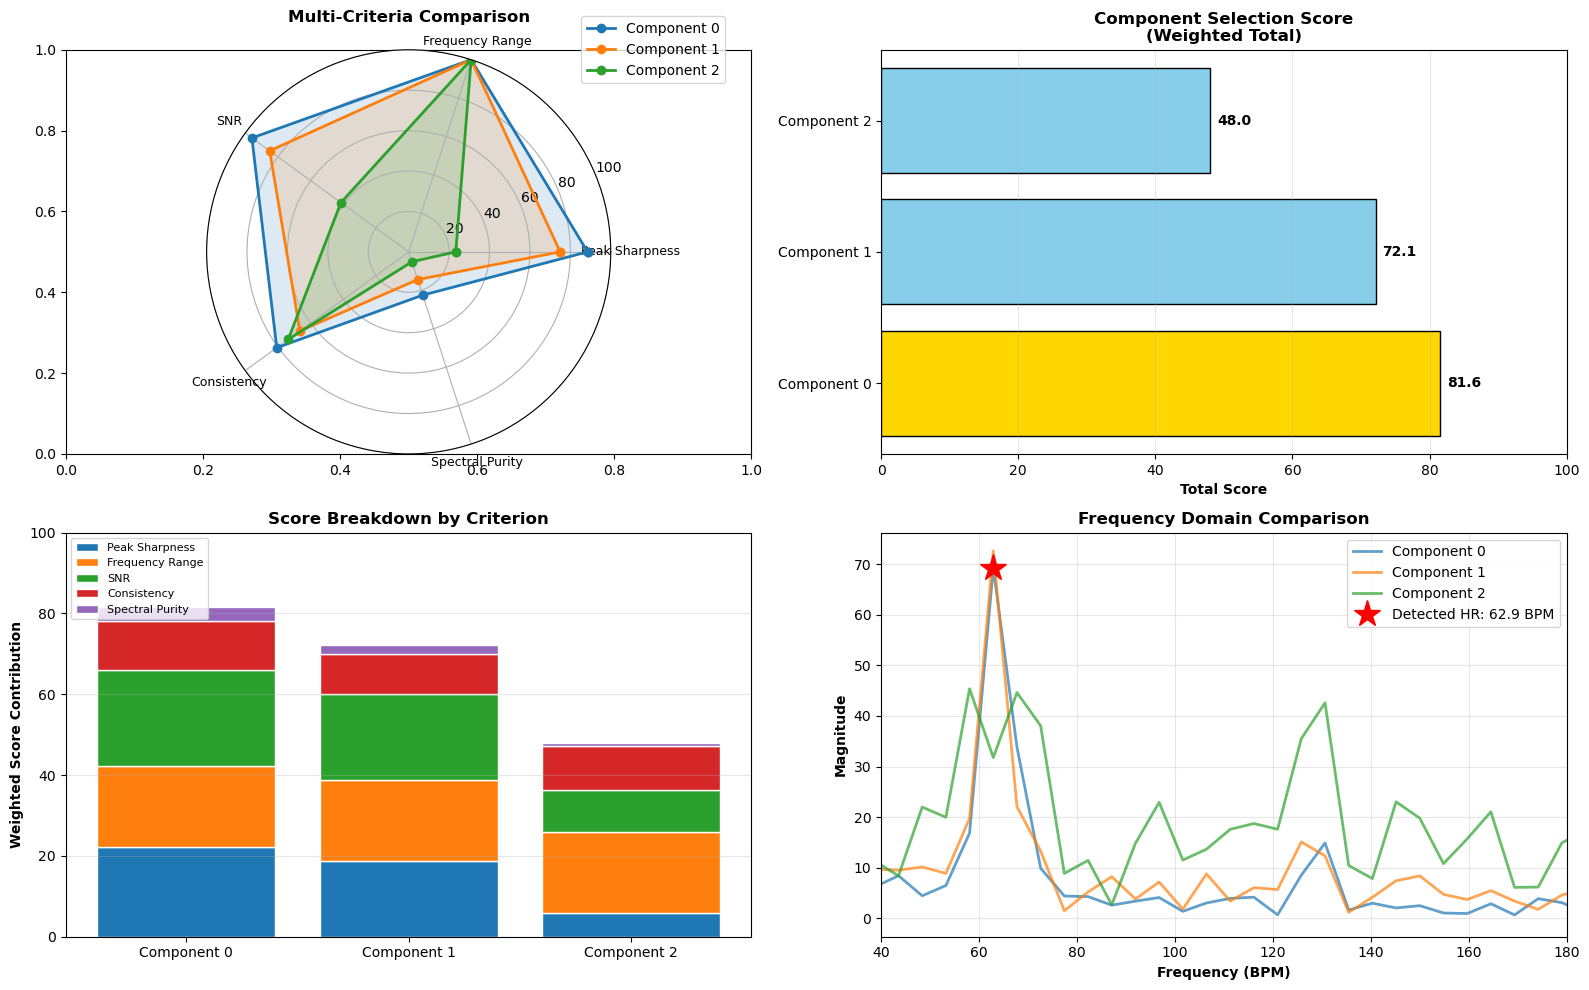


COMPONENT SELECTION ANALYSIS REPORT

Component 0:
  Peak Sharpness      :  88.5/100  (weight: 0.25, contribution:  22.1)
  Frequency Range     : 100.0/100  (weight: 0.20, contribution:  20.0)
  SNR                 :  95.9/100  (weight: 0.25, contribution:  24.0)
  Consistency         :  80.7/100  (weight: 0.15, contribution:  12.1)
  Spectral Purity     :  22.5/100  (weight: 0.15, contribution:   3.4)
  TOTAL SCORE         :  81.6/100

Component 1:
  Peak Sharpness      :  75.0/100  (weight: 0.25, contribution:  18.7)
  Frequency Range     : 100.0/100  (weight: 0.20, contribution:  20.0)
  SNR                 :  85.0/100  (weight: 0.25, contribution:  21.3)
  Consistency         :  66.5/100  (weight: 0.15, contribution:  10.0)
  Spectral Purity     :  14.4/100  (weight: 0.15, contribution:   2.2)
  TOTAL SCORE         :  72.1/100

Component 2:
  Peak Sharpness      :  23.3/100  (weight: 0.25, contribution:   5.8)
  Frequency Range     : 100.0/100  (weight: 0.20, contribution:  20.0)
 

In [15]:
# 10. Component Selection Score
# Automated scoring to identify which component is most likely the pulse

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

scores = {'Component 0': {}, 'Component 1': {}, 'Component 2': {}}
criteria_weights = {
    'Peak Sharpness': 0.25,
    'Frequency Range': 0.20,
    'SNR': 0.25,
    'Consistency': 0.15,
    'Spectral Purity': 0.15
}

for i in range(3):
    comp_name = f'Component {i}'
    
    fft_val = np.abs(np.fft.rfft(S_filtered[:, i]))
    freqs = np.fft.rfftfreq(len(S_filtered), 1/fs)
    freq_mask = (freqs * 60 >= 40) & (freqs * 60 <= 180)
    
    # Criterion 1: Peak Sharpness (how pronounced is the main peak)
    peak_power = np.max(fft_val[freq_mask])
    mean_power = np.mean(fft_val[freq_mask])
    peak_sharpness = peak_power / (mean_power + 1e-10)
    scores[comp_name]['Peak Sharpness'] = min(peak_sharpness / 10, 1.0) * 100
    
    # Criterion 2: Frequency Range (is the peak in realistic HR range: 50-90 BPM)
    peak_idx = np.argmax(fft_val[freq_mask])
    peak_freq_bpm = freqs[freq_mask][peak_idx] * 60
    if 50 <= peak_freq_bpm <= 90:
        freq_range_score = 1.0
    elif 40 <= peak_freq_bpm <= 120:
        freq_range_score = 0.7
    else:
        freq_range_score = 0.3
    scores[comp_name]['Frequency Range'] = freq_range_score * 100
    
    # Criterion 3: Signal-to-Noise Ratio
    noise_floor = np.percentile(fft_val[freq_mask], 25)
    snr = 20 * np.log10(peak_power / (noise_floor + 1e-10))
    scores[comp_name]['SNR'] = min(snr / 30, 1.0) * 100
    
    # Criterion 4: Consistency (how stable is the signal over time)
    # Use sliding window variance
    window_size = int(3 * fs)
    hop = int(fs)
    variances = []
    for start in range(0, len(S_filtered[:, i]) - window_size, hop):
        window_var = np.var(S_filtered[start:start+window_size, i])
        variances.append(window_var)
    consistency = 1.0 - min(np.std(variances) / (np.mean(variances) + 1e-10), 1.0)
    scores[comp_name]['Consistency'] = consistency * 100
    
    # Criterion 5: Spectral Purity (how concentrated is the power in narrow band)
    # Calculate spectral entropy
    psd_norm = fft_val[freq_mask] / (np.sum(fft_val[freq_mask]) + 1e-10)
    spectral_entropy = -np.sum(psd_norm * np.log2(psd_norm + 1e-10))
    max_entropy = np.log2(len(psd_norm))
    spectral_purity = 1.0 - (spectral_entropy / max_entropy)
    scores[comp_name]['Spectral Purity'] = spectral_purity * 100

# Calculate total weighted scores
total_scores = {}
for comp in scores:
    total = sum(scores[comp][criterion] * criteria_weights[criterion] 
                for criterion in criteria_weights)
    total_scores[comp] = total

# 10.1 Radar chart of criteria
categories = list(criteria_weights.keys())
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

ax1 = plt.subplot(221, projection='polar')
for i, (comp, score_dict) in enumerate(scores.items()):
    values = [score_dict[cat] for cat in categories]
    values += values[:1]
    ax1.plot(angles, values, 'o-', linewidth=2, label=comp)
    ax1.fill(angles, values, alpha=0.15)

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories, size=9)
ax1.set_ylim(0, 100)
ax1.set_title('Multi-Criteria Comparison', fontweight='bold', pad=20)
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax1.grid(True)

# 10.2 Bar chart of total scores
ax2 = plt.subplot(222)
components = list(total_scores.keys())
values = list(total_scores.values())
colors = ['gold' if v == max(values) else 'skyblue' for v in values]
bars = ax2.barh(components, values, color=colors, edgecolor='black')
ax2.set_xlabel('Total Score', fontweight='bold')
ax2.set_title('Component Selection Score\n(Weighted Total)', fontweight='bold')
ax2.set_xlim(0, 100)
for i, (bar, val) in enumerate(zip(bars, values)):
    ax2.text(val + 1, i, f'{val:.1f}', va='center', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# 10.3 Stacked bar chart showing contribution of each criterion
ax3 = plt.subplot(223)
criterion_names = list(criteria_weights.keys())
comp_names = list(scores.keys())
bottom = np.zeros(3)

for criterion in criterion_names:
    values = [scores[comp][criterion] * criteria_weights[criterion] for comp in comp_names]
    ax3.bar(comp_names, values, bottom=bottom, label=criterion, edgecolor='white')
    bottom += values

ax3.set_ylabel('Weighted Score Contribution', fontweight='bold')
ax3.set_title('Score Breakdown by Criterion', fontweight='bold')
ax3.legend(loc='upper left', fontsize=8)
ax3.set_ylim(0, 100)
ax3.grid(True, alpha=0.3, axis='y')

# 10.4 Frequency peaks of all components
ax4 = plt.subplot(224)
for i in range(3):
    fft_val = np.abs(np.fft.rfft(S_filtered[:, i]))
    freqs = np.fft.rfftfreq(len(S_filtered), 1/fs)
    ax4.plot(freqs * 60, fft_val, label=f'Component {i}', linewidth=2, alpha=0.7)

ax4.set_xlim(40, 180)
ax4.set_xlabel('Frequency (BPM)', fontweight='bold')
ax4.set_ylabel('Magnitude', fontweight='bold')
ax4.set_title('Frequency Domain Comparison', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Highlight the best component's peak
best_comp = int(max(total_scores, key=total_scores.get).split()[1])
fft_val_best = np.abs(np.fft.rfft(S_filtered[:, best_comp]))
freqs_best = np.fft.rfftfreq(len(S_filtered), 1/fs)
freq_mask_best = (freqs_best * 60 >= 40) & (freqs_best * 60 <= 180)
peak_idx_best = np.argmax(fft_val_best[freq_mask_best])
peak_freq_best = freqs_best[freq_mask_best][peak_idx_best] * 60
peak_power_best = fft_val_best[freq_mask_best][peak_idx_best]
ax4.plot(peak_freq_best, peak_power_best, 'r*', markersize=20, 
         label=f'Detected HR: {peak_freq_best:.1f} BPM')
ax4.legend()

plt.tight_layout()
plt.show()

# Print detailed report
print("\n" + "="*60)
print("COMPONENT SELECTION ANALYSIS REPORT")
print("="*60)

for comp in scores:
    print(f"\n{comp}:")
    for criterion, score in scores[comp].items():
        weight = criteria_weights[criterion]
        contribution = score * weight
        print(f"  {criterion:20s}: {score:5.1f}/100  (weight: {weight:.2f}, contribution: {contribution:5.1f})")
    print(f"  {'TOTAL SCORE':20s}: {total_scores[comp]:5.1f}/100")

best_component = max(total_scores, key=total_scores.get)
print("\n" + "="*60)
print(f"🏆 RECOMMENDED: {best_component}")
print(f"   Score: {total_scores[best_component]:.1f}/100")

# Get the heart rate from the best component
best_comp_idx = int(best_component.split()[1])
fft_val = np.abs(np.fft.rfft(S_filtered[:, best_comp_idx]))
freqs = np.fft.rfftfreq(len(S_filtered), 1/fs)
freq_mask = (freqs * 60 >= 40) & (freqs * 60 <= 180)
peak_idx = np.argmax(fft_val[freq_mask])
heart_rate = freqs[freq_mask][peak_idx] * 60

print(f"   Estimated Heart Rate: {heart_rate:.1f} BPM")
print("="*60)

### Plot Interpretation: Component Selection

**Radar Chart (Top-left):** Each component is overlaid as a polygon. The component whose polygon covers the most area (largest across all criteria) is the best candidate. This gives a quick visual comparison of strengths and weaknesses.

**Bar Chart (Top-right):** The weighted total scores. The gold bar highlights the winning component. A clear margin between the winner and others indicates high confidence in the selection.

**Stacked Bar Chart (Bottom-left):** Shows the contribution of each criterion to the total score. This reveals *why* a component scored well — e.g., high SNR but poor frequency range. Useful for understanding edge cases where the recommendation might be uncertain.

**Frequency Domain (Bottom-right):** All three components' spectra overlaid, with a red star marking the detected heart rate from the best component. This final view confirms that the selected component's peak is sharp and in a physiologically plausible range.

### Summary

The automated analysis selects the component with the strongest, cleanest periodic signal in the heart rate range. The detailed report at the bottom lists all criteria scores and identifies the recommended component with its estimated heart rate.